# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

**TODO**: *Add your implementation plan here*

### Step 1: Set up the environment

In [1]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [1]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
# Import necessary libraries
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household_qat

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [4]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [5]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA A10)']


In [6]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


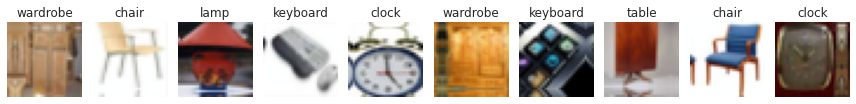


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


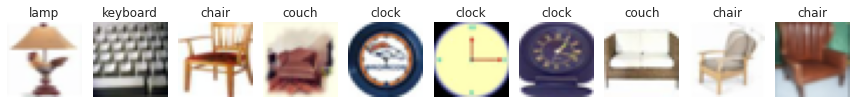

In [7]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [8]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
#baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth", map_location='cpu'))

print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [9]:
list_experiments()

['baseline_mobilenet',
 'in_training/distillation/temp3_alpha0-7_epochs20',
 'in_training/distillation/temp3_alpha0-7_epochs50',
 'in_training/quantization/epochs100_start1000',
 'in_training/quantization/epochs150_start1000',
 'in_training/quantization/epochs200_start',
 'in_training/quantization/epochs200_start1000',
 'post_training/graph_optimization/torch_fx_cpu',
 'post_training/pruning/global_unstructured_0-4_cpu',
 'post_training/quantization/dynamic']

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [10]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.
        
        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        #self.current_model = None
        self.steps = []
        self.results = {}
        
        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"
        
        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)
    
    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.
        
        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        self.steps.append({
            'name': step_name,
            'function': step_function,
            'args': kwargs
        })
        return self
    
    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.
        
        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)
            
        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")
        
        # Start with the baseline model
        #current_model = self.baseline_model
        
        # Save intermediate results after each step
        step_results = []
        
        # TODO: Run the pipeline iteratively
        # For each stage in the pipeline:
        # 1. Apply the specified technique with the given parameters
        # 2. Evaluate the model after applying the technique
        # 3. Store the results for later comparison
        for i, step in enumerate(self.steps):
            print(f"\n{'-'*50}")
            print(f"Step {i+1}: {step['name']}")
            print(f"{'-'*50}\n")
            if i > 0:
                step['args'] = {'model': current_model, 'submod': True}
            current_model, metrics, comparison_results, experiment_name = step['function'](**step['args'])
            step_results.append({
                'step_name': experiment_name,
                'metrics': metrics,
                'comparison_results': comparison_results
                })

            
            # ...Add your code here...
        
        self.optimized_model = current_model
        final_path = f"{self.model_dir}/model.{file_extension}"
        
        # TODO: Save final model
        # Remember that different pytorch model format will require different saving mechanisms
        save_model(self.optimized_model, final_path)
        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_metrics': metrics,  # As returned by evaluate_optimized_model()
            'final_comparison': comparison_results  # As returned by compare_optimized_model_to_baseline()
        }
        
        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)
        
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"{'='*50}\n")
        
        return self.optimized_model
    
    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device==torch.device('cpu') else 'cuda'

        # Extract metrics from each step
        step_names = [step['step_name'] for step in self.results['steps']]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in self.results['steps']]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in self.results['steps']]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in self.results['steps']]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in self.results['steps']]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1-TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1-TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1-TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  ✅ Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_memory_size:.2f} MB)")


        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1-TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  ✅ Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  ❌ Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1-MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  ✅ Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  ❌ Does not meet target (Goal: ≥{min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  ✅ Pipeline meets all requirements")
        else:
            print(f"  ❌ Pipeline does not meet all requirements")

In [11]:
# TODO: Create helper functions for each compression technique you want to experiment with as a pipeline step
# Remember to parametrize the functions appropriately
def apply_post_training_pruning():
    pass
def apply_in_training_pruning():
    pass
def apply_in_training_quantization():
    %reload_ext autoreload

# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model=None):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    #### Apply quantization-aware training
    ## Find info at https://pytorch.org/docs/stable/quantization.html
    ## Create quantizable model version
    ## TODO: Check the model implementation in the `compression/` folder
    torch.cuda.empty_cache()
    model = QuantizableMobileNetV3_Household_qat(dropout_rate=0.2, quantize=False)
    print(model)

    # TODO: Experiment with different configurations
    ## We recommend testing testing with various start and freeze epochs
    ## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
    torch.cuda.empty_cache()
    num_epochs = 200

    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',        # 'min' for loss, 'max' for accuracy/metric
        factor=0.9,        # LR is multiplied by this factor
        patience=10,       # Number of epochs with no improvement before reducing LR
        threshold=0.0001,  # Minimum change to qualify as improvement
        cooldown=0,        # Number of epochs to wait before resuming normal operation
        min_lr=1e-6,       # Lower bound for LR
    )

    config = {
        'start_qat': True, #Boolean
        'freeze_bn_epochs': 3,  # Integer
        'num_epochs': num_epochs,  # Integer
        'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
        'optimizer': optimizer,  # A PyTorch optimizer
        'scheduler': scheduler,  # A PyTorch scheduler
        'patience': 100,  # Integer
        'device': torch.device('cuda'),  # Define with torch.device()
        'device_for_inference': torch.device('cpu'),  # Define with torch.device()
        'grad_clip_norm': None,  # Float
    }
    backend = "qnnpack"  # One of "fbgemm" or "qnnpack"

    # Extract relevant training parameters for logging
    #qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    num_epochs = config['num_epochs']
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/epochs{num_epochs}_start" #{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    if config['start_qat']:
        print(f"Applying quantization-aware training with QAT starting at epoch 0 / ending at {num_epochs}")
    else:
        print("Quantization aware training start epoch will be set dynamically once test accuracy > 0.88")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER   
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"{os.getcwd()}/../models/{experiment_name}/checkpoints",  # Providing full path to manage different sub-directory depths in utility scripts
        backend=backend,
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=qat_stats,
        device=config["device_for_inference"],
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=config["device_for_inference"],
    )
    
    return quantized_model, metrics, comparison_results, experiment_name


In [12]:
def apply_knowledge_distillation(model=None):
    ## Load the pre-trained teacher model
    baseline_model_name = "baseline_mobilenet"
    teacher_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth")
    teacher_model.eval()  # Teacher should be in eval mode

    ## Create student model
    ## TODO: Check the model implementation in the `compression/` folder
    student_model = MobileNetV3_Household_Small(num_classes=len(class_names), width_mult=1, linear_size=16, dropout=0.3) #, weights=None)
    ## Uncomment print below to inspect the student model architecture
    #print_model_summary(student_model)

    optimizer = torch.optim.AdamW(student_model.parameters(), lr=0.0004)#, weight_decay=1e-4)  # A PyTorch optimizer
    print("Optimizer created")
    criterion = nn.CrossEntropyLoss()
    print("Cross entropy loss created")
    # TODO: EXPERIMENT WITH DIFFERENT TRAINING PARAMETERS
    # We recommend testing distillation with different alpha and temperature
    ## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
    config = {
        'num_epochs': 50,  # Integer
        'criterion': criterion,  # A PyTorch loss
        'optimizer': optimizer,  # A PyTorch optimizer
        'scheduler': None,  # A PyTorch scheduler
        'alpha': 0.7,  # Float
        'temperature': 3,  # Float
        'patience': 50,  # Integer
        'device':  torch.device('cuda'),  # Define with torch.device()
        }

    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, metrics, comparison_results, experiment_name

In [13]:
def apply_dynamic_quantization(model=None, submod=False):
    quantization_type = 'dynamic'
    baseline_model_name = "baseline_mobilenet"
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}"
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    backend = 'fbgemm'
    print(f"Applying {quantization_type} quantization with {backend} backend")
    device = 'cpu'
    if not submod:
        # Make a copy of the baseline model and move to specified device
        orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
        orig_model.eval()
    else:
        orig_model = model
        orig_model.to(device)
        orig_model.eval()

    print_model_summary(orig_model)
    
    # Apply post-training quantization
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER    
    quantized_model = quantize_model(
        orig_model,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=len(train_loader) if quantization_type == "static" else None,  # Set this to the desired value
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, metrics, comparison_results, experiment_name

In [14]:
def apply_graph_optimization(model=None, submod=False):
    ## TODO: EXPERIMENT WITH DIFFERENT  PARAMETERS
    ## We recommend testing testing with both optimization methods and device types
    ## Feel free to add more configuration parameters (and update the script in `compression/` folder accordingly)
    optimization_method = "torch_fx"  # One of "torch_fx" or "torchscript"
    device = torch.device('cpu')  # Define with torch.device()

    # Optimize and evaluate model
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    if not submod:
        orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    else:
        orig_model = model
        orig_model.to(device)

    input_shape=input_size
    # Apply graph optimization
    # TODO: IMPLEMENT THIS FUNCTION IN THE compression/ FOLDER 
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"
    save_model(optimized_model, f"../models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return optimized_model, metrics, comparison_results, experiment_name

#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.

[{'name': 'DQuant', 'function': <function apply_dynamic_quantization at 0x7d15dc9e6f80>, 'args': {}}, {'name': 'GraphOpt', 'function': <function apply_graph_optimization at 0x7d15dc9e67a0>, 'args': {}}]

Running pipeline: QuantGraphOpt


--------------------------------------------------
Step 1: DQuant
--------------------------------------------------

Applying dynamic quantization with fbgemm backend
Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, mome

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.45it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  6.20it/s]


Confusion matrix saved to ../results/post_training/quantization/dynamic/confusion_matrix.png


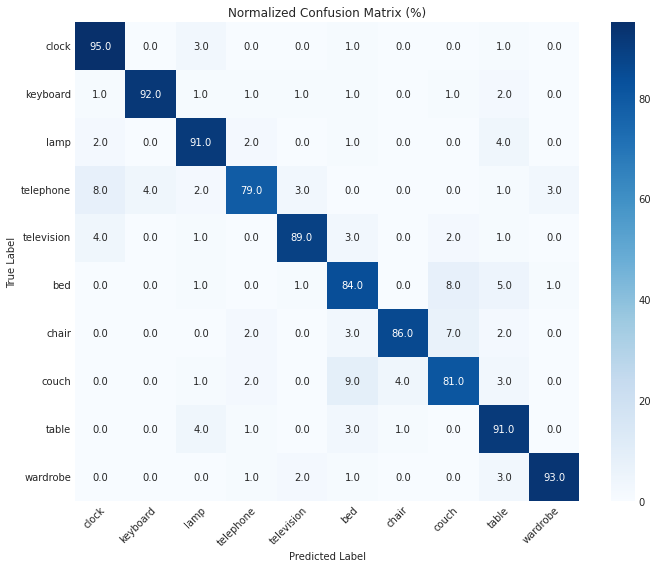


Optimized Model Metrics (post_training/quantization/dynamic):
Accuracy: 88.10%
Model Size: 4.24 MB
CPU Inference Time: 473.72 ms (2.11 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.46it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic/comparison.png


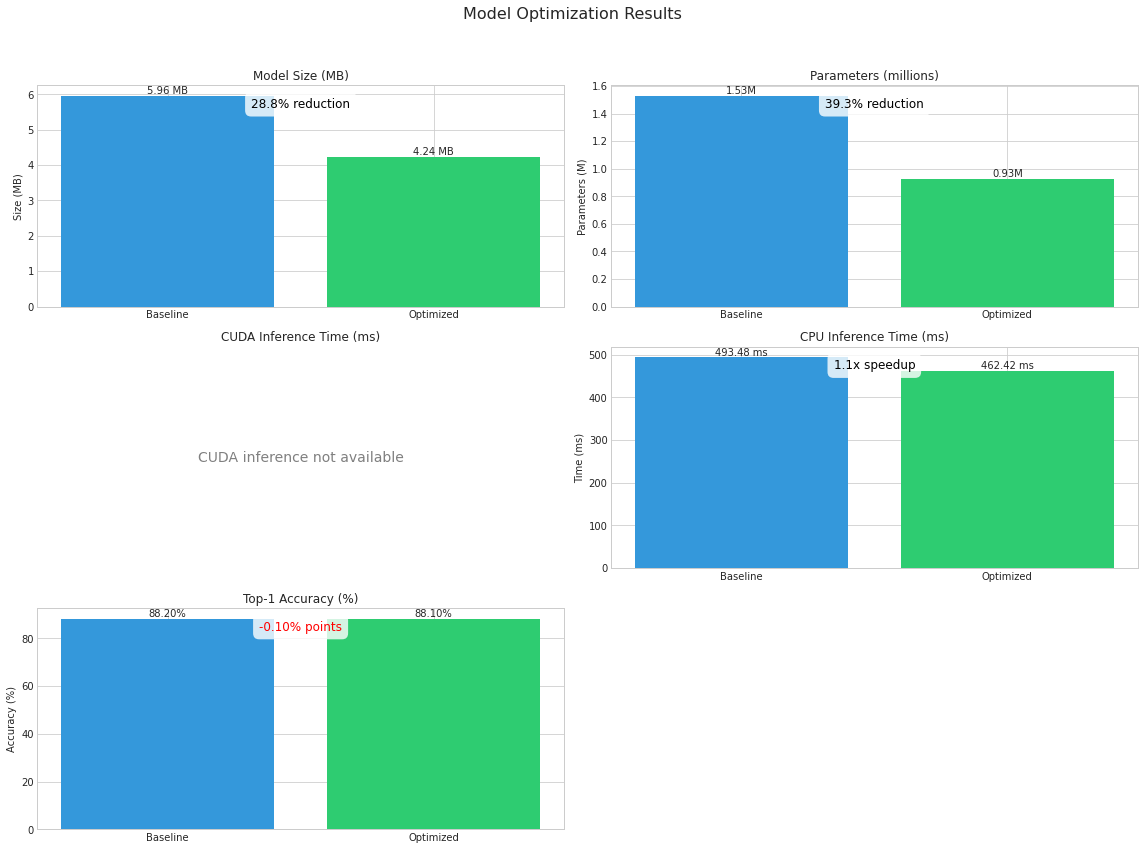


post_training/quantization/dynamic Results:
Model Size: 4.24 MB (28.8% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 462.42 ms (1.1x speedup)
Accuracy: 88.10% (-0.10% change)
Requirements met: False

--------------------------------------------------
Step 2: GraphOpt
--------------------------------------------------

Applying optimization with torch_fx as method
Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.06it/s]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.16it/s]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


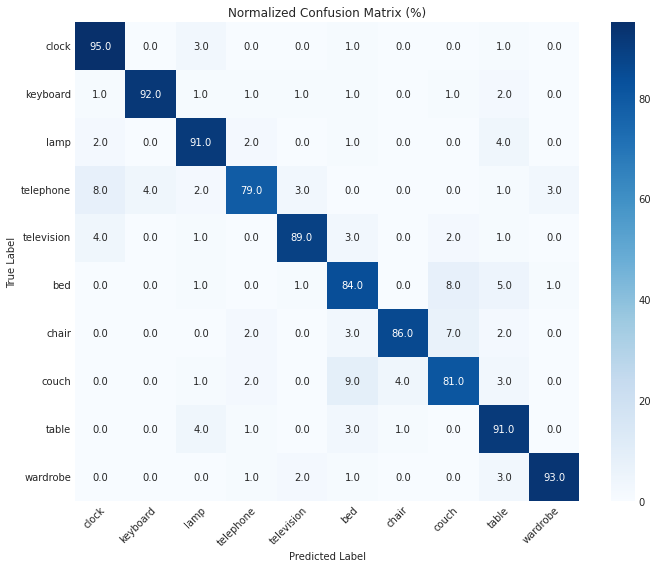


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 88.10%
Model Size: 4.13 MB
CPU Inference Time: 280.91 ms (3.56 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  6.60it/s]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


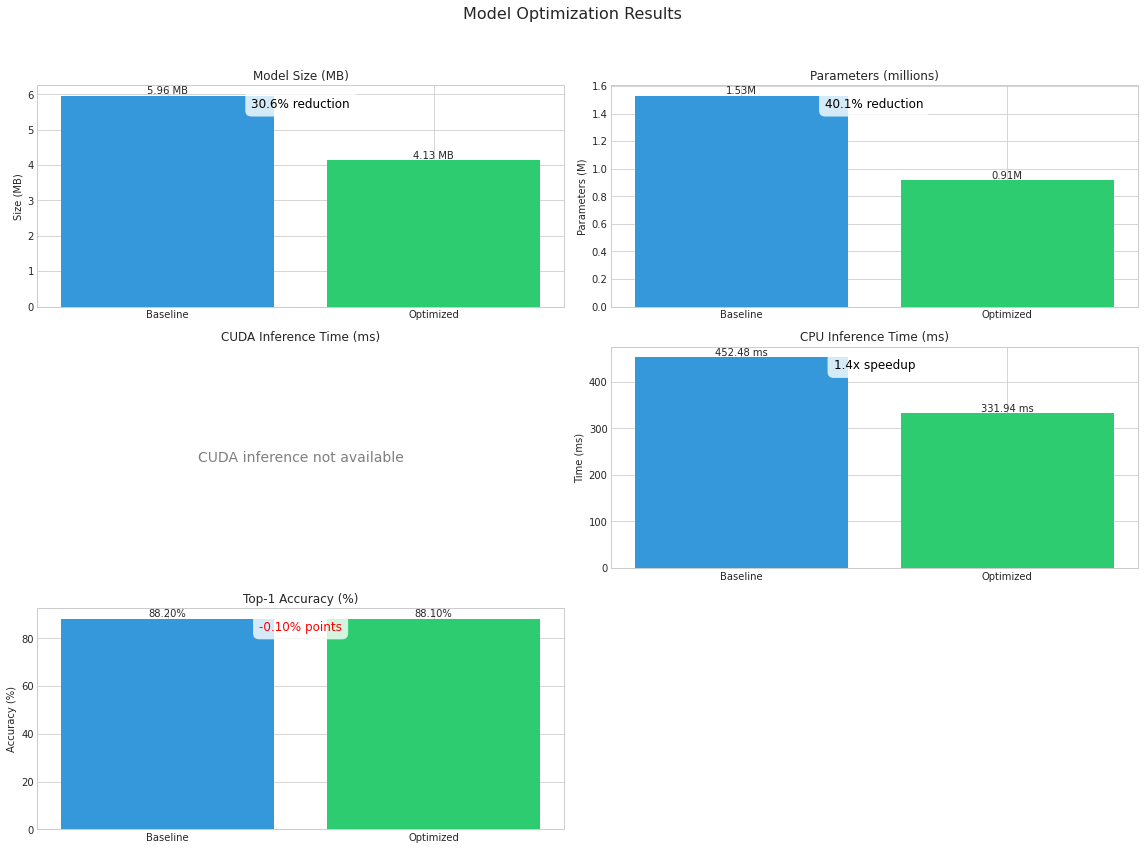


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 4.13 MB (30.6% reduction)
Parameters: 914,896 (40.1% reduction)
CPU Inference Time: 331.94 ms (1.4x speedup)
Accuracy: 88.10% (-0.10% change)
Requirements met: False
Model saved to ../models/pipeline/QuantGraphOpt/model.pth

Pipeline QuantGraphOpt completed



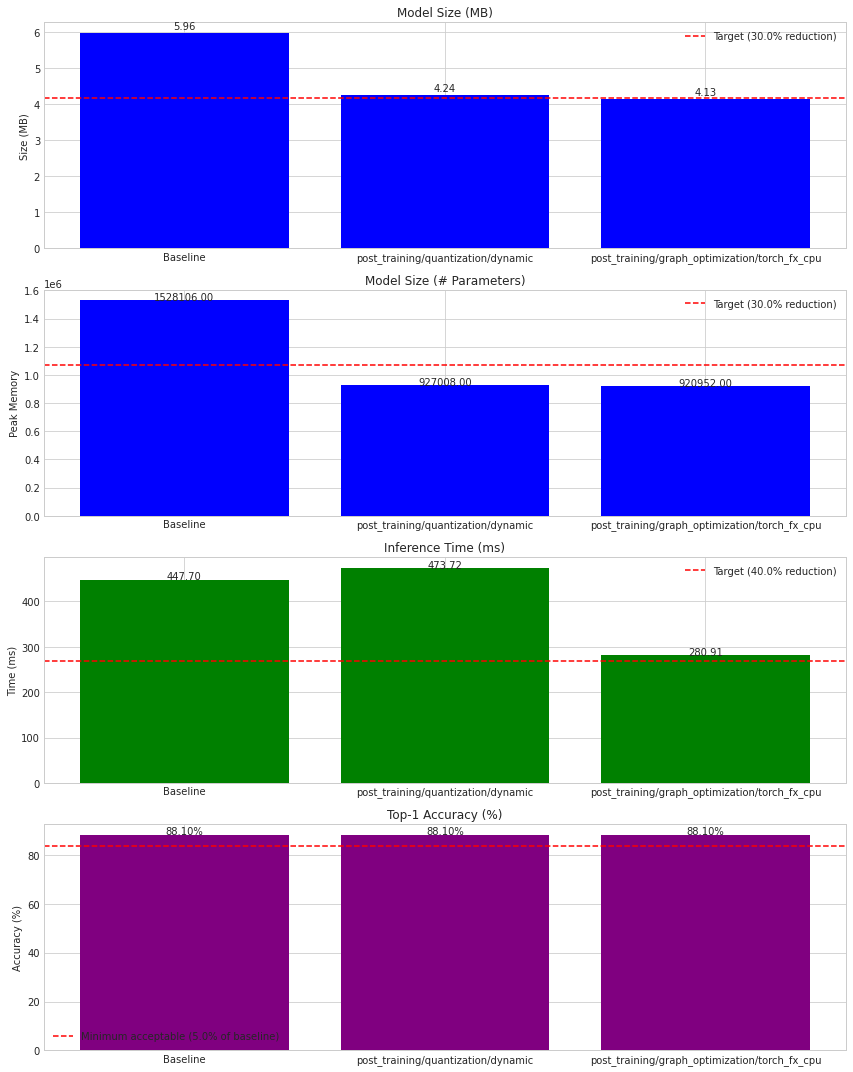


Pipeline QuantGraphOpt Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 4.13 MB
  Reduction: 30.68%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 920952.00 MB
  Reduction: 39.73%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 447.70 ms
  Final: 280.91 ms
  Reduction: 37.25%
  ❌ Does not meet target (Goal: 268.62 ms)

Accuracy:
  Baseline: 88.10%
  Final: 88.10%
  Change: 0.00%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [15]:
# Create and run Pipeline #1

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "QuantGraphOpt"  

# Initialize the pipeline
pipeline1 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=None,
    train_loader=None,
    test_loader=None,
    class_names=None,
    input_size=None
)

# TODO: Add optimization steps using the add_step() function
pipeline1.add_step(step_name="DQuant", step_function=apply_dynamic_quantization)
pipeline1.add_step(step_name="GraphOpt",step_function=apply_graph_optimization)

print(pipeline1.steps)

# Run the pipeline
optimized_model_p1 = pipeline1.run()

# Visualize the results
# # TODO: Choose the device to report performance for
device = torch.device('cpu')  # Define as torch.device()
pipeline1.visualize_results(baseline_metrics, device)

In [15]:
input_size

(1, 3, 32, 32)

[{'name': 'Distill', 'function': <function apply_knowledge_distillation at 0x7d15dc9e7010>, 'args': {'model': None}}, {'name': 'GraphOpt', 'function': <function apply_graph_optimization at 0x7d15dc9e67a0>, 'args': {}}]

Running pipeline: DistillGraphOpt


--------------------------------------------------
Step 1: Distill
--------------------------------------------------

Optimizer created
Cross entropy loss created
Applying knowledge distillation with temperature=3 and alpha=0.7
Student parameters: 936,410
Teacher parameters: 1,528,106
Training with knowledge distillation for 50 epochs
Temperature: 3, Alpha: 0.7


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 33.25it/s, loss=2.96, acc=53.5]


Epoch 1/50 - Train Loss: 8.2992, Train Acc: 39.86%, Test Loss: 1.4784, Test Acc: 53.50%, LR: 0.000400, Time: 3.35s
New best student model! Saving... (53.50%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.44it/s, loss=2.62, acc=61.4]


Epoch 2/50 - Train Loss: 5.3598, Train Acc: 60.74%, Test Loss: 1.3102, Test Acc: 61.40%, LR: 0.000400, Time: 2.96s
New best student model! Saving... (61.40%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


...

Epoch 50/50 - Train Loss: 1.2531, Train Acc: 94.22%, Test Loss: 0.4075, Test Acc: 88.60%, LR: 0.000400, Time: 2.99s
Distillation completed. Best student accuracy: 89.50%
Best student model saved as '../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth' at epoch 47
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.35it/s]


Baseline metrics saved at ../results/in_training/distillation/temp3_alpha0-7_epochs50/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 36.87it/s]


Confusion matrix saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/confusion_matrix.png


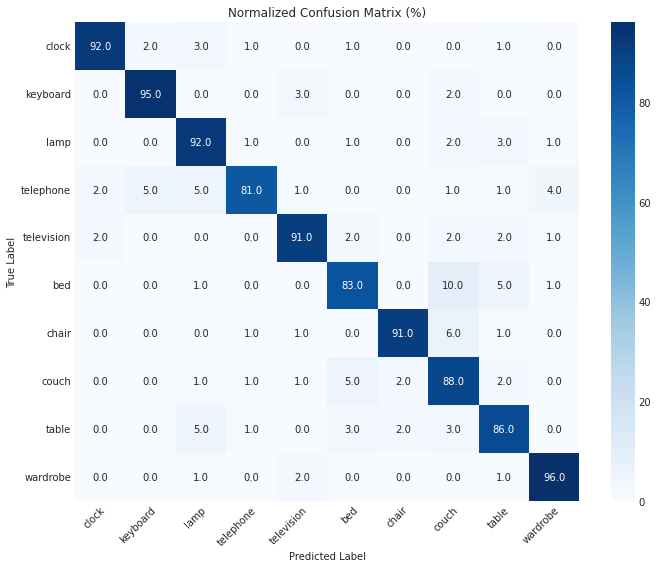

Weight distribution plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/weight_distribution.png


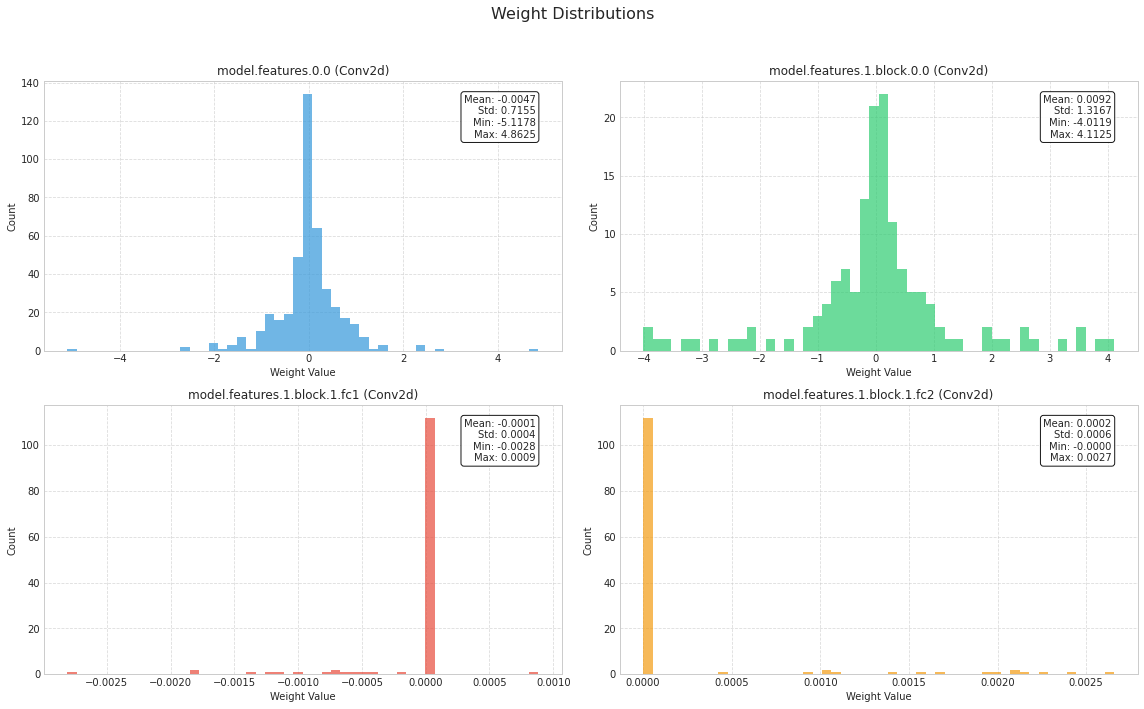

Training history plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/training_history.png


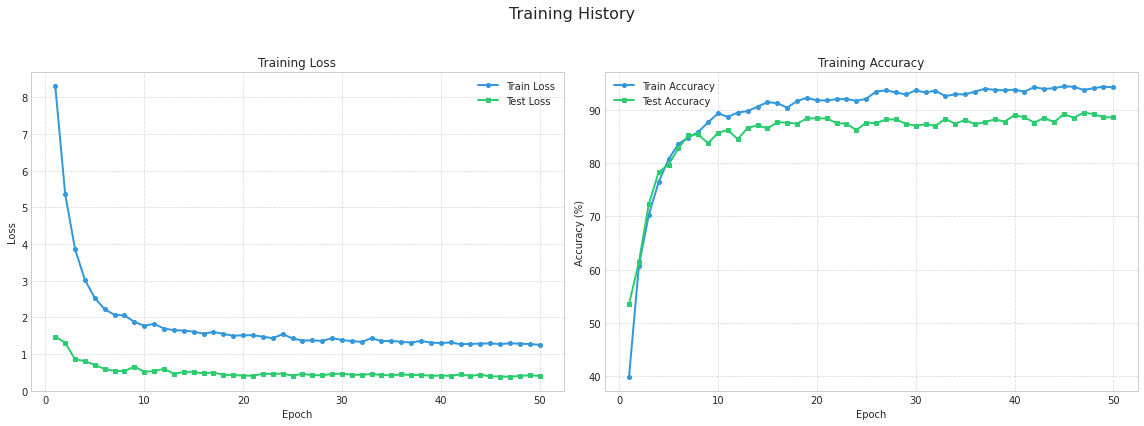


Optimized Model Metrics (in_training/distillation/temp3_alpha0-7_epochs50):
Accuracy: 89.50%
Model Size: 3.70 MB
CPU Inference Time: 414.00 ms (2.42 FPS)
CUDA Inference Time: 3.26 ms (306.58 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.56it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.22it/s]


Model comparison plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/comparison.png


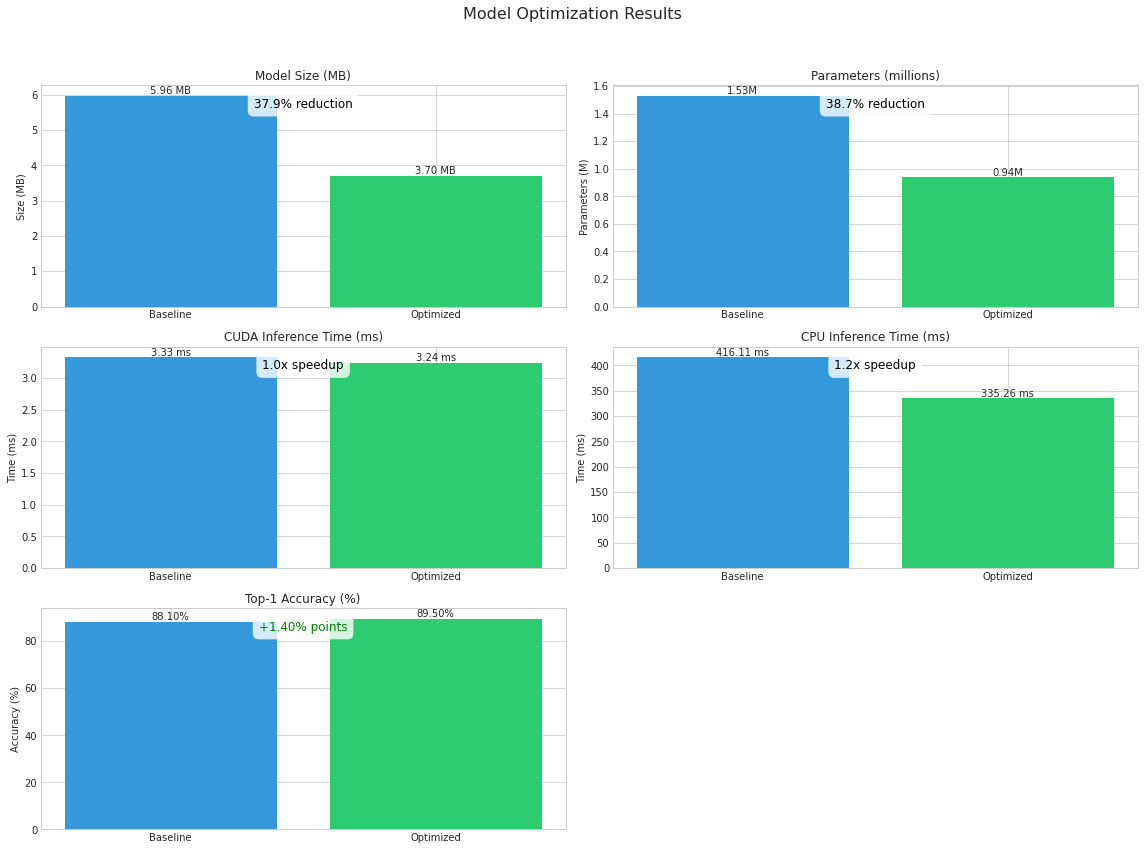


in_training/distillation/temp3_alpha0-7_epochs50 Results:
Model Size: 3.70 MB (37.9% reduction)
Parameters: 936,410 (38.7% reduction)
CPU Inference Time: 335.26 ms (1.2x speedup)
CUDA Inference Time: 3.24 ms (1.0x speedup)
Accuracy: 89.50% (+1.40% change)
Requirements met: False

--------------------------------------------------
Step 2: GraphOpt
--------------------------------------------------

Applying optimization with torch_fx as method
Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


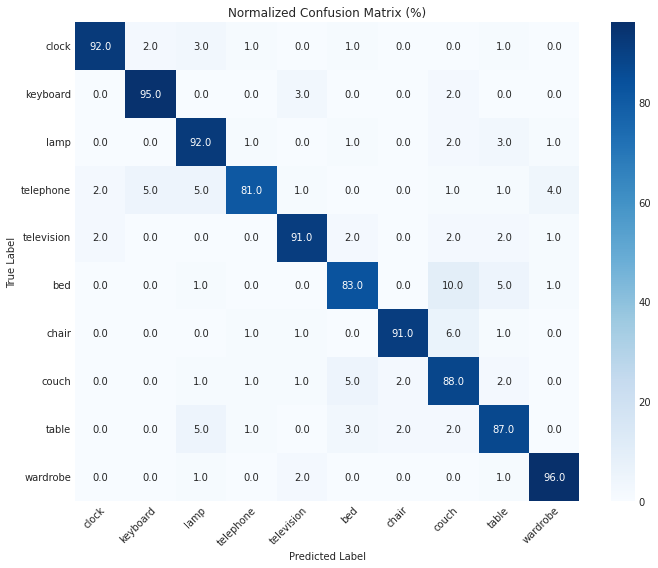


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 89.60%
Model Size: 3.59 MB
CPU Inference Time: 305.33 ms (3.28 FPS)
CUDA Inference Time: 2.66 ms (375.64 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.84it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


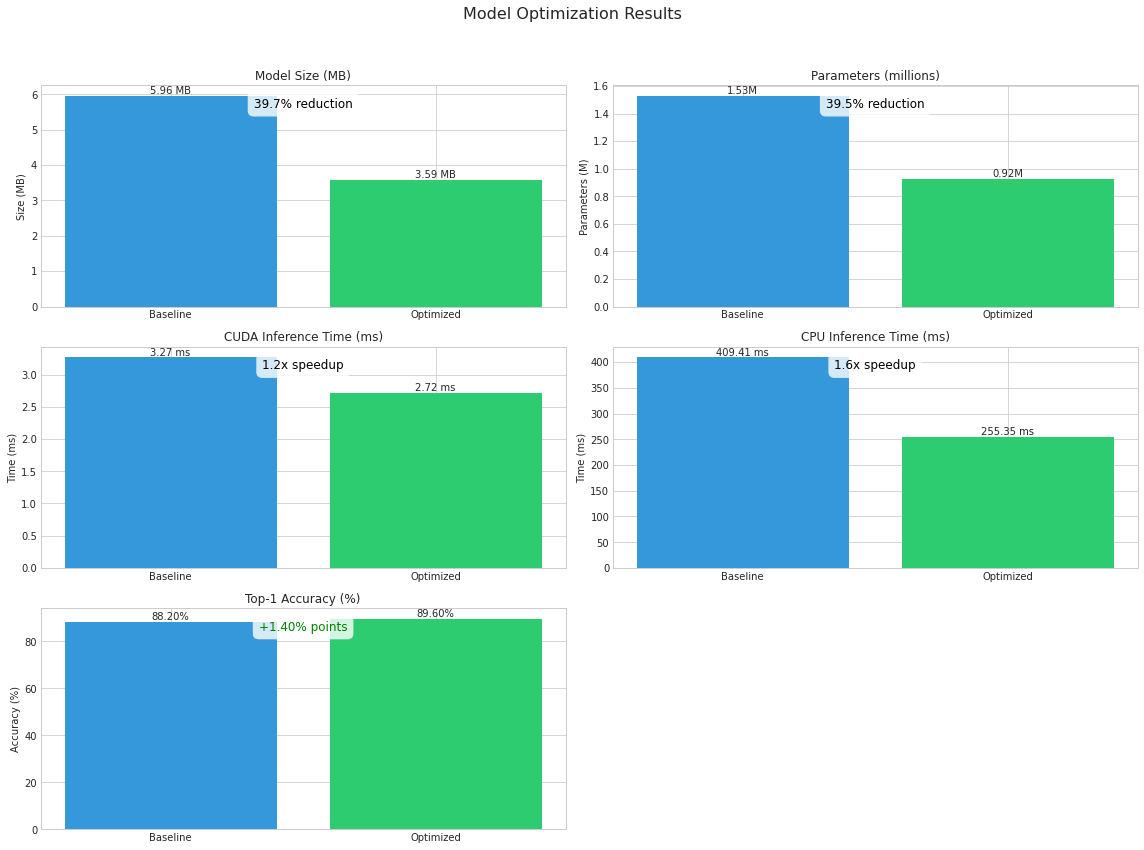


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 3.59 MB (39.7% reduction)
Parameters: 924,298 (39.5% reduction)
CPU Inference Time: 255.35 ms (1.6x speedup)
CUDA Inference Time: 2.72 ms (1.2x speedup)
Accuracy: 89.60% (+1.40% change)
Requirements met: False
Model saved to ../models/pipeline/DistillGraphOpt/model.pth

Pipeline DistillGraphOpt completed



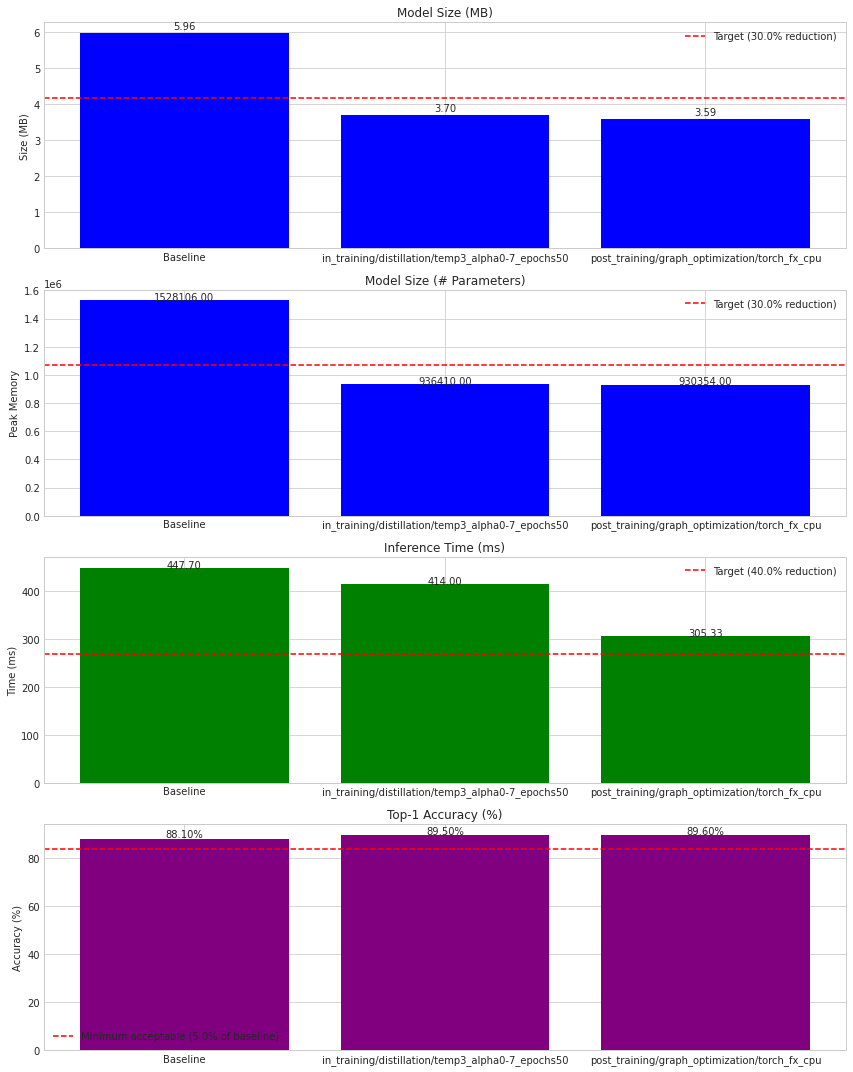


Pipeline DistillGraphOpt Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 3.59 MB
  Reduction: 39.77%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 930354.00 MB
  Reduction: 39.12%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 447.70 ms
  Final: 305.33 ms
  Reduction: 31.80%
  ❌ Does not meet target (Goal: 268.62 ms)

Accuracy:
  Baseline: 88.10%
  Final: 89.60%
  Change: 1.70%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [16]:
# Create and run Pipeline #2

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "DistillGraphOpt"  

# Initialize the pipeline
pipeline2 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=None,
    train_loader=None,
    test_loader=None,
    class_names=None,
    input_size=None
)

# TODO: Add optimization steps using the add_step() function
pipeline2.add_step(step_name="Distill", step_function=apply_knowledge_distillation, model=None)
pipeline2.add_step(step_name="GraphOpt",step_function=apply_graph_optimization)

print(pipeline2.steps)

# Run the pipeline
optimized_model_p2 = pipeline2.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device('cpu') # Define as torch.device()
pipeline2.visualize_results(baseline_metrics, device)


[{'name': 'Distill', 'function': <function apply_knowledge_distillation at 0x7d15dc9e7010>, 'args': {'model': None}}, {'name': 'Quant', 'function': <function apply_dynamic_quantization at 0x7d15dc9e6f80>, 'args': {}}]

Running pipeline: DistillQuant


--------------------------------------------------
Step 1: Distill
--------------------------------------------------

Optimizer created
Cross entropy loss created
Applying knowledge distillation with temperature=3 and alpha=0.7
Student parameters: 936,410
Teacher parameters: 1,528,106
Training with knowledge distillation for 50 epochs
Temperature: 3, Alpha: 0.7


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.54it/s, loss=2.96, acc=53.5]


Epoch 1/50 - Train Loss: 8.2992, Train Acc: 39.86%, Test Loss: 1.4784, Test Acc: 53.50%, LR: 0.000400, Time: 2.97s
New best student model! Saving... (53.50%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.62it/s, loss=2.62, acc=61.4]


Epoch 2/50 - Train Loss: 5.3598, Train Acc: 60.74%, Test Loss: 1.3102, Test Acc: 61.40%, LR: 0.000400, Time: 2.96s
New best student model! Saving... (61.40%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


...

Epoch 50/50 - Train Loss: 1.2531, Train Acc: 94.22%, Test Loss: 0.4075, Test Acc: 88.60%, LR: 0.000400, Time: 3.00s
Distillation completed. Best student accuracy: 89.50%
Best student model saved as '../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth' at epoch 47
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.19it/s]


Baseline metrics saved at ../results/in_training/distillation/temp3_alpha0-7_epochs50/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 36.03it/s]


Confusion matrix saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/confusion_matrix.png


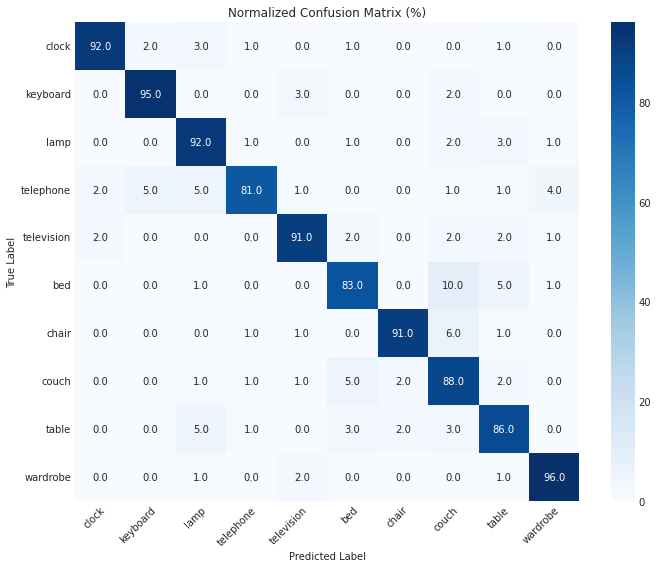

Weight distribution plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/weight_distribution.png


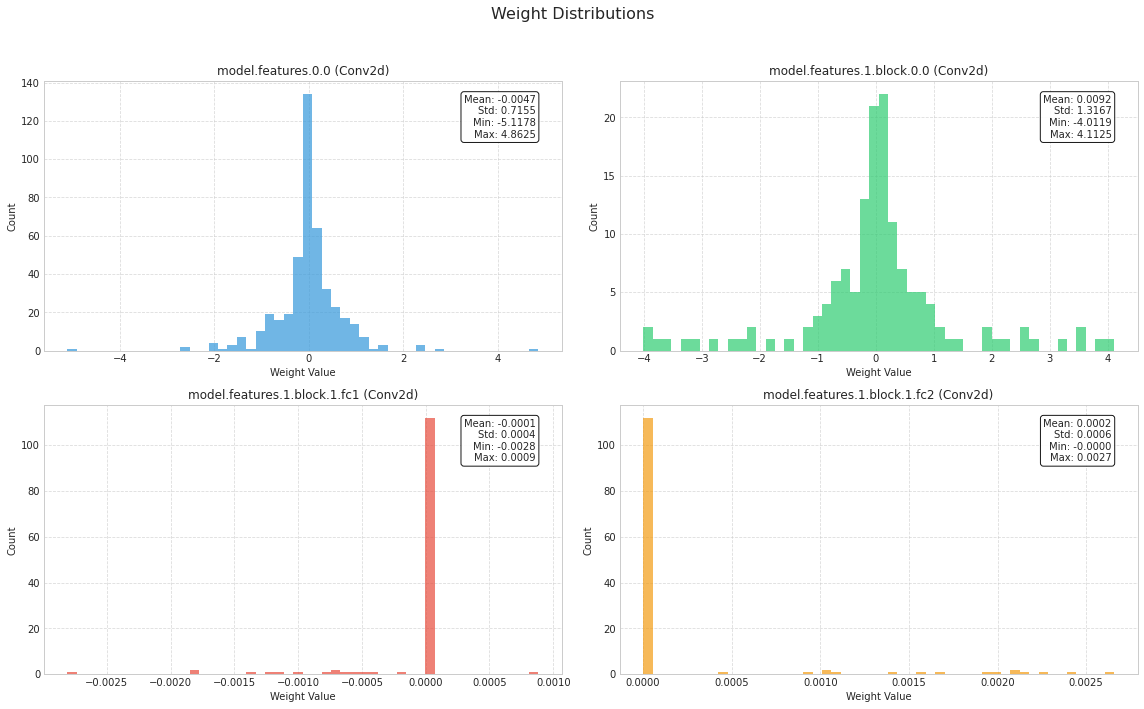

Training history plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/training_history.png


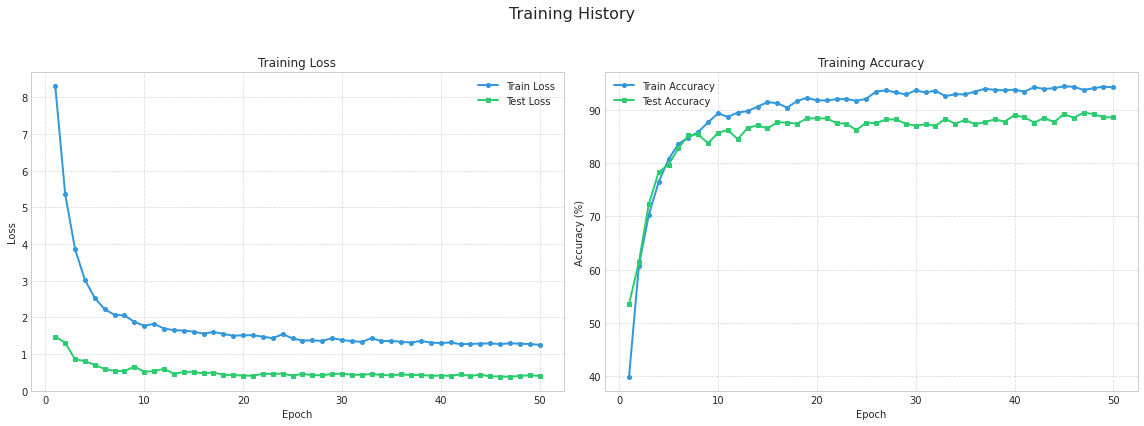


Optimized Model Metrics (in_training/distillation/temp3_alpha0-7_epochs50):
Accuracy: 89.50%
Model Size: 3.70 MB
CPU Inference Time: 406.47 ms (2.46 FPS)
CUDA Inference Time: 3.23 ms (309.72 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.00it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 34.78it/s]


Model comparison plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/comparison.png


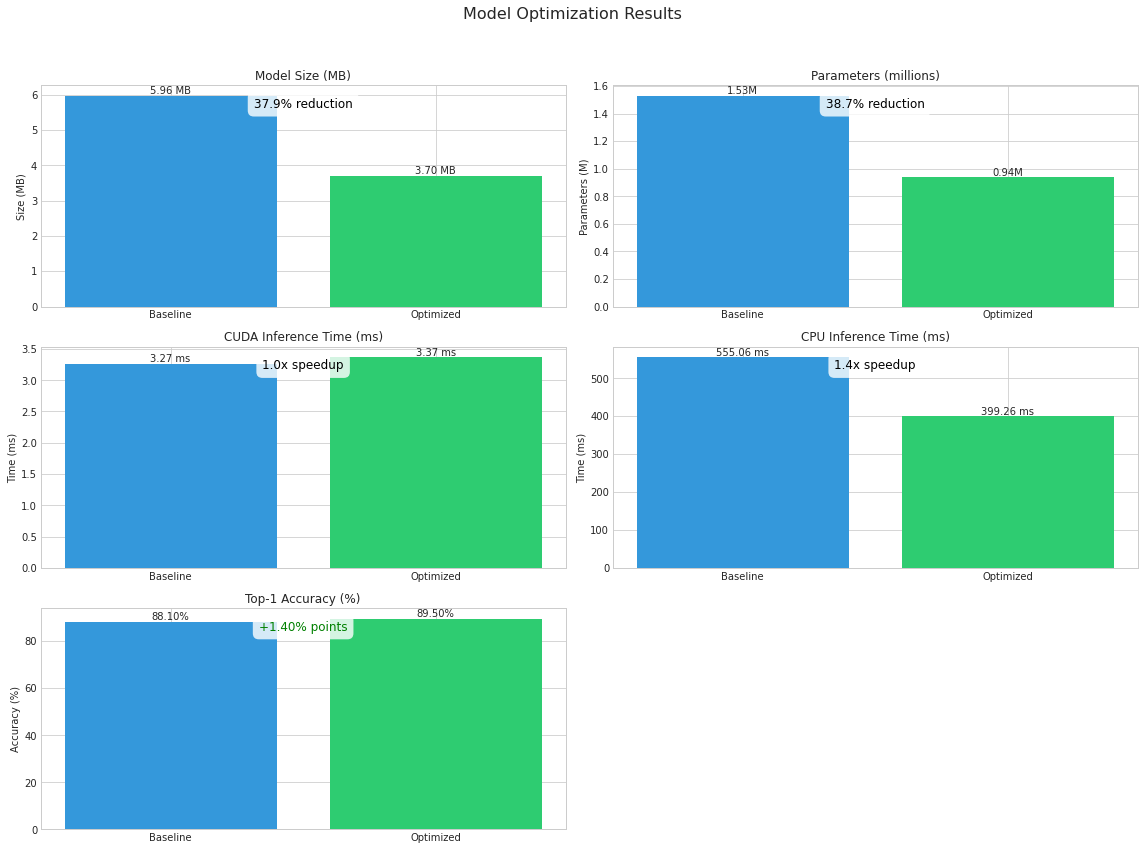


in_training/distillation/temp3_alpha0-7_epochs50 Results:
Model Size: 3.70 MB (37.9% reduction)
Parameters: 936,410 (38.7% reduction)
CPU Inference Time: 399.26 ms (1.4x speedup)
CUDA Inference Time: 3.37 ms (1.0x speedup)
Accuracy: 89.50% (+1.40% change)
Requirements met: False

--------------------------------------------------
Step 2: Quant
--------------------------------------------------

Applying dynamic quantization with fbgemm backend
Model Architecture:
MobileNetV3_Household_Small(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.14it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  4.98it/s]


Confusion matrix saved to ../results/post_training/quantization/dynamic/confusion_matrix.png


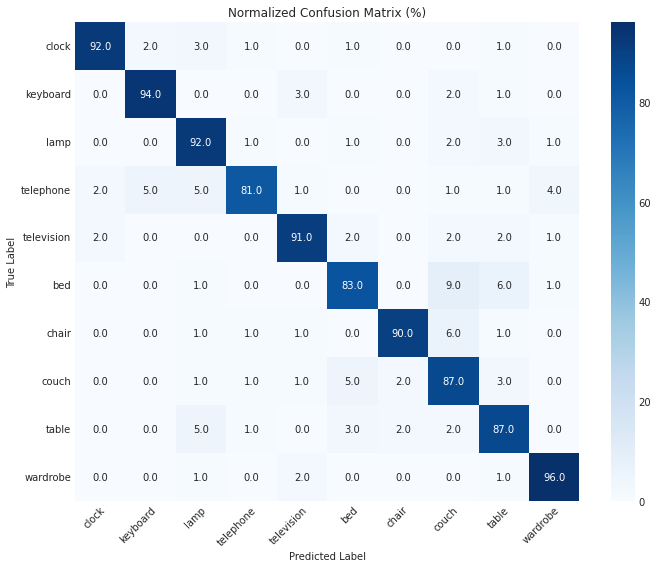


Optimized Model Metrics (post_training/quantization/dynamic):
Accuracy: 89.30%
Model Size: 3.67 MB
CPU Inference Time: 384.56 ms (2.60 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.75it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.03it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic/comparison.png


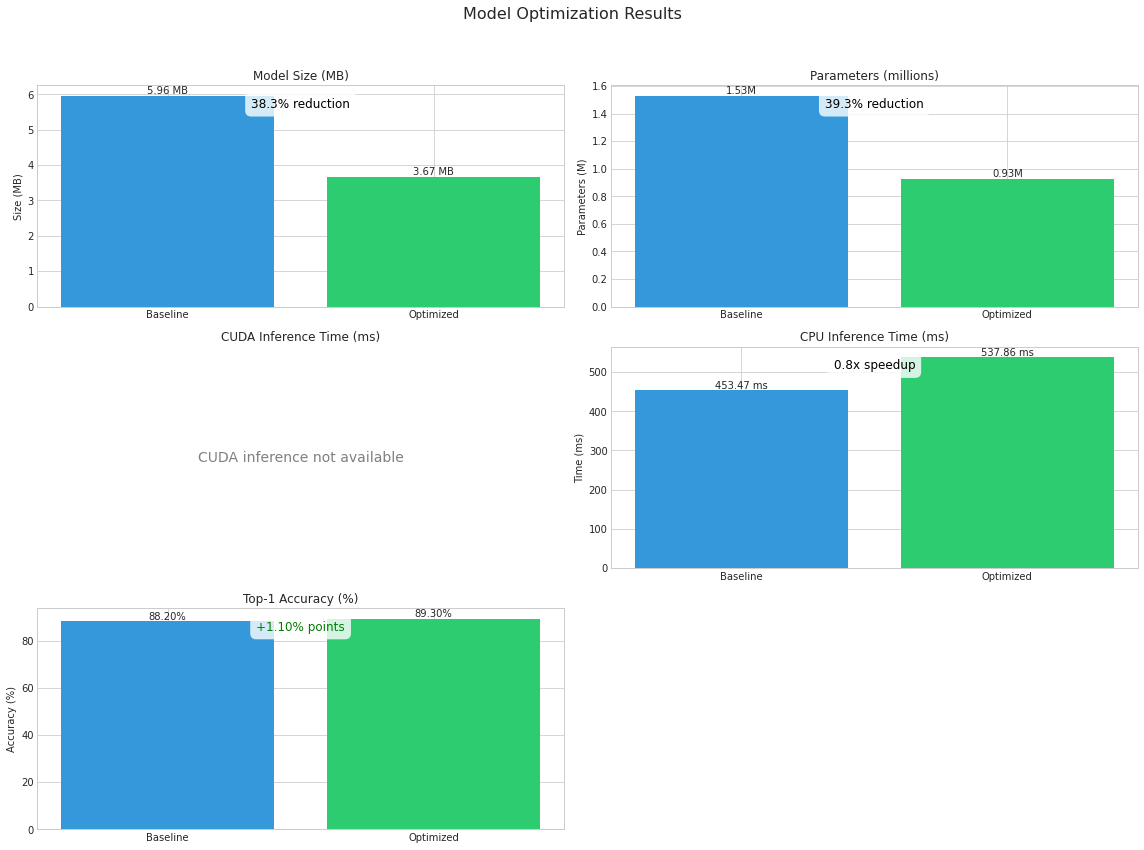


post_training/quantization/dynamic Results:
Model Size: 3.67 MB (38.3% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 537.86 ms (0.8x speedup)
Accuracy: 89.30% (+1.10% change)
Requirements met: False
Model saved to ../models/pipeline/DistillQuant/model.pth

Pipeline DistillQuant completed



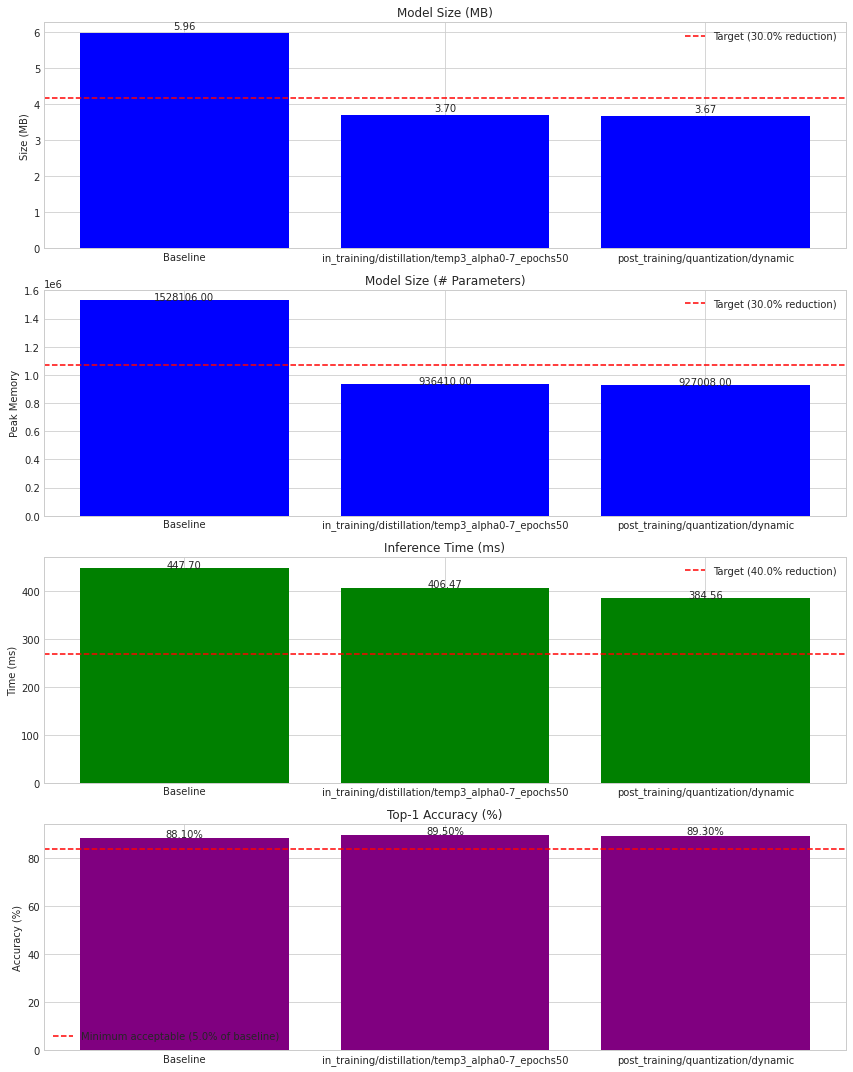


Pipeline DistillQuant Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 3.67 MB
  Reduction: 38.35%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 927008.00 MB
  Reduction: 39.34%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 447.70 ms
  Final: 384.56 ms
  Reduction: 14.10%
  ❌ Does not meet target (Goal: 268.62 ms)

Accuracy:
  Baseline: 88.10%
  Final: 89.30%
  Change: 1.36%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [17]:
# Create and run Pipeline #3

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "DistillQuant"  

# Initialize the pipeline
pipeline3 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=None,
    train_loader=None,
    test_loader=None,
    class_names=None,
    input_size=None
)

# TODO: Add optimization steps using the add_step() function
pipeline3.add_step(step_name="Distill", step_function=apply_knowledge_distillation, model=None)
pipeline3.add_step(step_name="Quant",step_function=apply_dynamic_quantization)

print(pipeline3.steps)

# Run the pipeline
optimized_model_p3 = pipeline3.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device('cpu')  # Define as torch.device()
pipeline3.visualize_results(baseline_metrics, device)


[{'name': 'Distill', 'function': <function apply_knowledge_distillation at 0x7d15dc9e7010>, 'args': {'model': None}}, {'name': 'Quant', 'function': <function apply_dynamic_quantization at 0x7d15dc9e6f80>, 'args': {}}, {'name': 'GraphOpt', 'function': <function apply_graph_optimization at 0x7d15dc9e67a0>, 'args': {}}]

Running pipeline: DistillQuantGraphOpt


--------------------------------------------------
Step 1: Distill
--------------------------------------------------

Optimizer created
Cross entropy loss created
Applying knowledge distillation with temperature=3 and alpha=0.7
Student parameters: 936,410
Teacher parameters: 1,528,106
Training with knowledge distillation for 50 epochs
Temperature: 3, Alpha: 0.7


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.77it/s, loss=3.76, acc=39.4]


Epoch 1/50 - Train Loss: 8.3203, Train Acc: 34.58%, Test Loss: 1.8815, Test Acc: 39.40%, LR: 0.000400, Time: 2.97s
New best student model! Saving... (39.40%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.59it/s, loss=2.39, acc=59]  


Epoch 2/50 - Train Loss: 5.6280, Train Acc: 50.42%, Test Loss: 1.1954, Test Acc: 59.00%, LR: 0.000400, Time: 2.97s
New best student model! Saving... (59.00%)
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth


...

Epoch 50/50 - Train Loss: 1.2023, Train Acc: 94.92%, Test Loss: 0.3861, Test Acc: 89.40%, LR: 0.000400, Time: 3.01s
Distillation completed. Best student accuracy: 89.90%
Best student model saved as '../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth' at epoch 48
Model saved to ../models/in_training/distillation/temp3_alpha0-7_epochs50/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 35.10it/s]


Baseline metrics saved at ../results/in_training/distillation/temp3_alpha0-7_epochs50/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 36.28it/s]


Confusion matrix saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/confusion_matrix.png


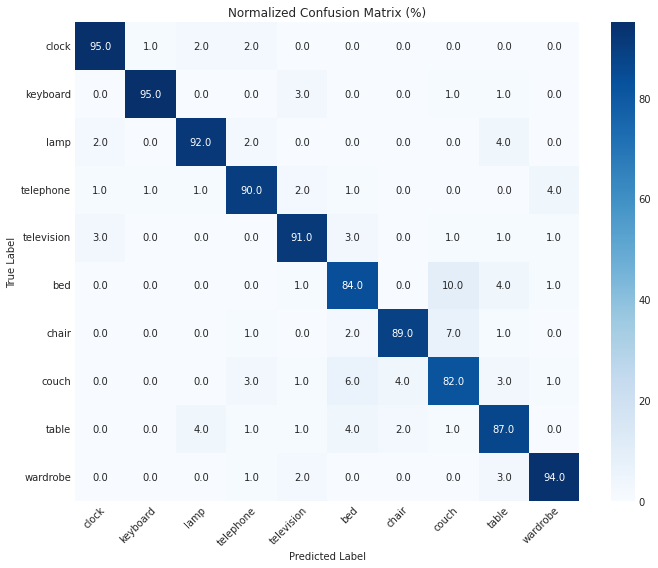

Weight distribution plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/weight_distribution.png


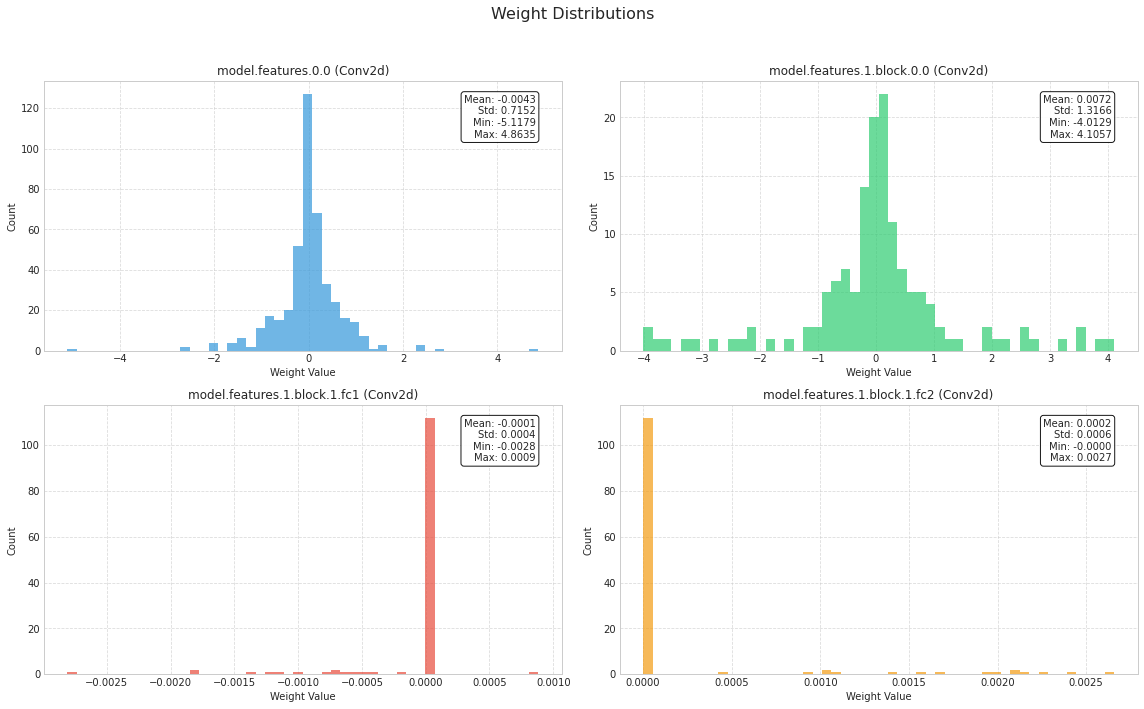

Training history plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/training_history.png


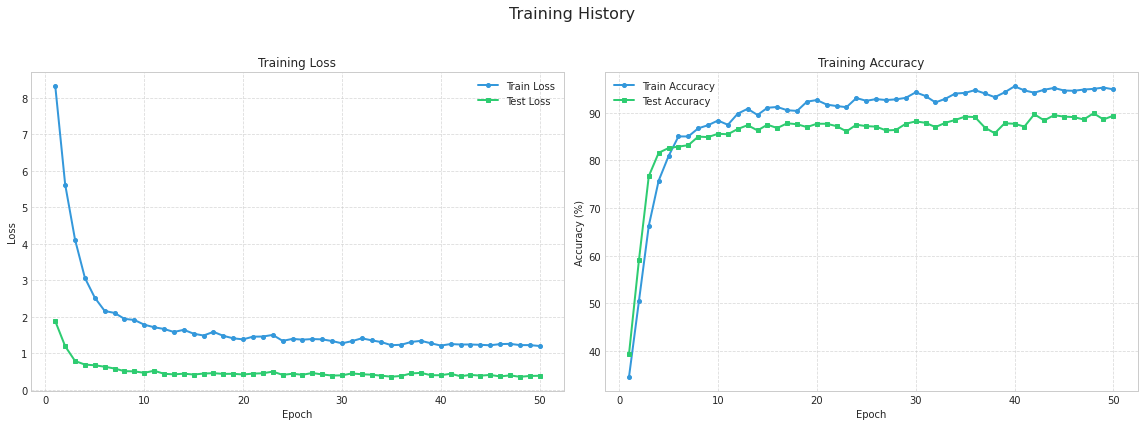


Optimized Model Metrics (in_training/distillation/temp3_alpha0-7_epochs50):
Accuracy: 89.90%
Model Size: 3.70 MB
CPU Inference Time: 379.82 ms (2.63 FPS)
CUDA Inference Time: 3.27 ms (305.71 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 34.62it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 34.35it/s]


Model comparison plot saved to ../results/in_training/distillation/temp3_alpha0-7_epochs50/comparison.png


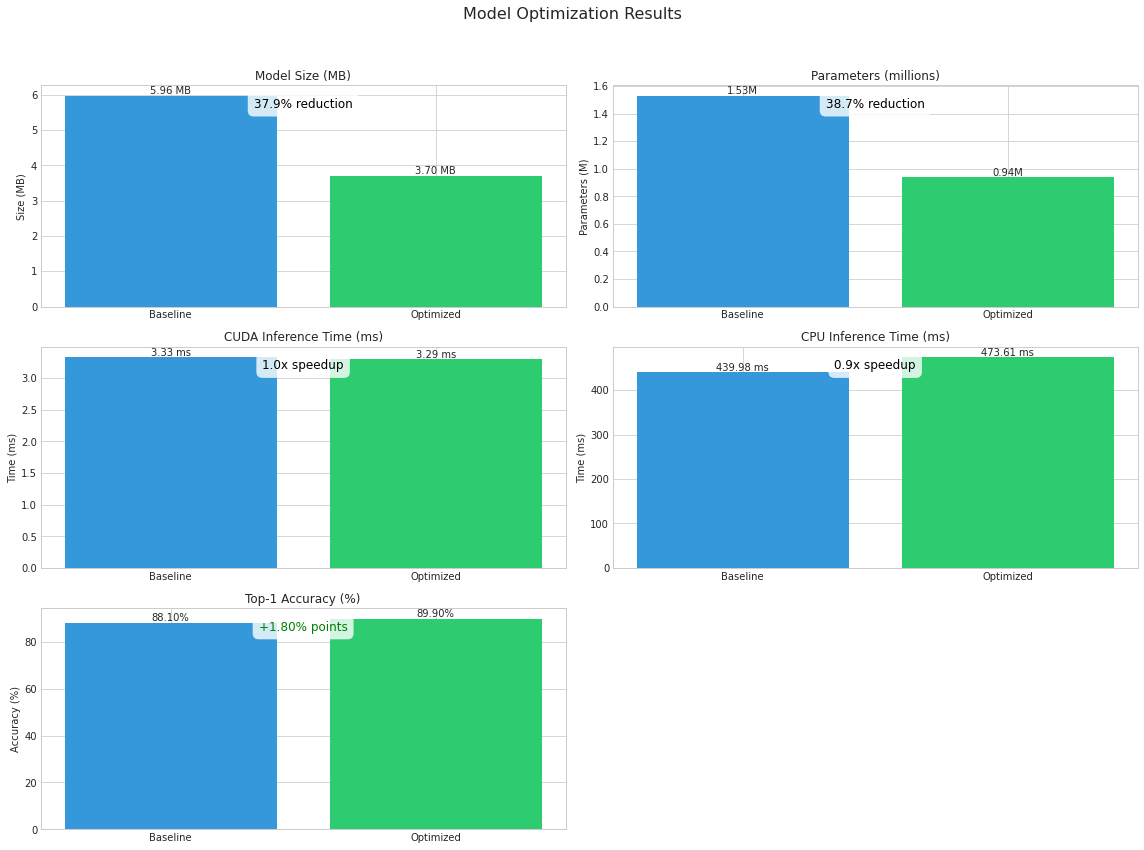


in_training/distillation/temp3_alpha0-7_epochs50 Results:
Model Size: 3.70 MB (37.9% reduction)
Parameters: 936,410 (38.7% reduction)
CPU Inference Time: 473.61 ms (0.9x speedup)
CUDA Inference Time: 3.29 ms (1.0x speedup)
Accuracy: 89.90% (+1.80% change)
Requirements met: False

--------------------------------------------------
Step 2: Quant
--------------------------------------------------

Applying dynamic quantization with fbgemm backend
Model Architecture:
MobileNetV3_Household_Small(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)

Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.12it/s]


Baseline metrics saved at ../results/post_training/quantization/dynamic/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.11it/s]


Confusion matrix saved to ../results/post_training/quantization/dynamic/confusion_matrix.png


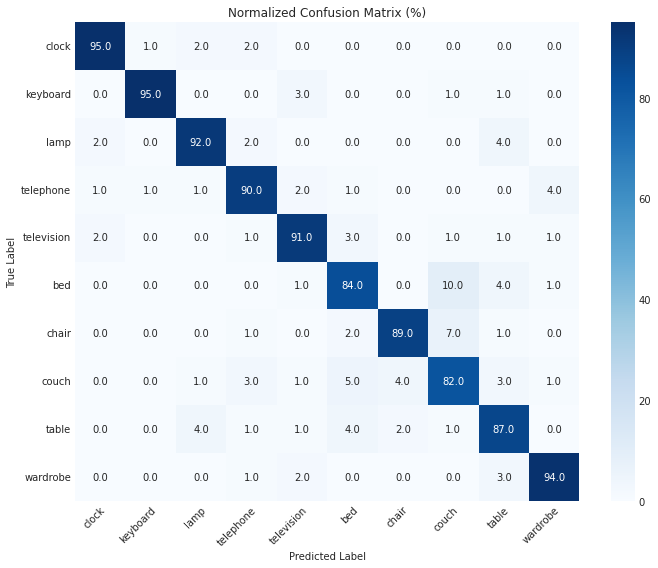


Optimized Model Metrics (post_training/quantization/dynamic):
Accuracy: 89.90%
Model Size: 3.67 MB
CPU Inference Time: 499.68 ms (2.00 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.84it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.88it/s]


Model comparison plot saved to ../results/post_training/quantization/dynamic/comparison.png


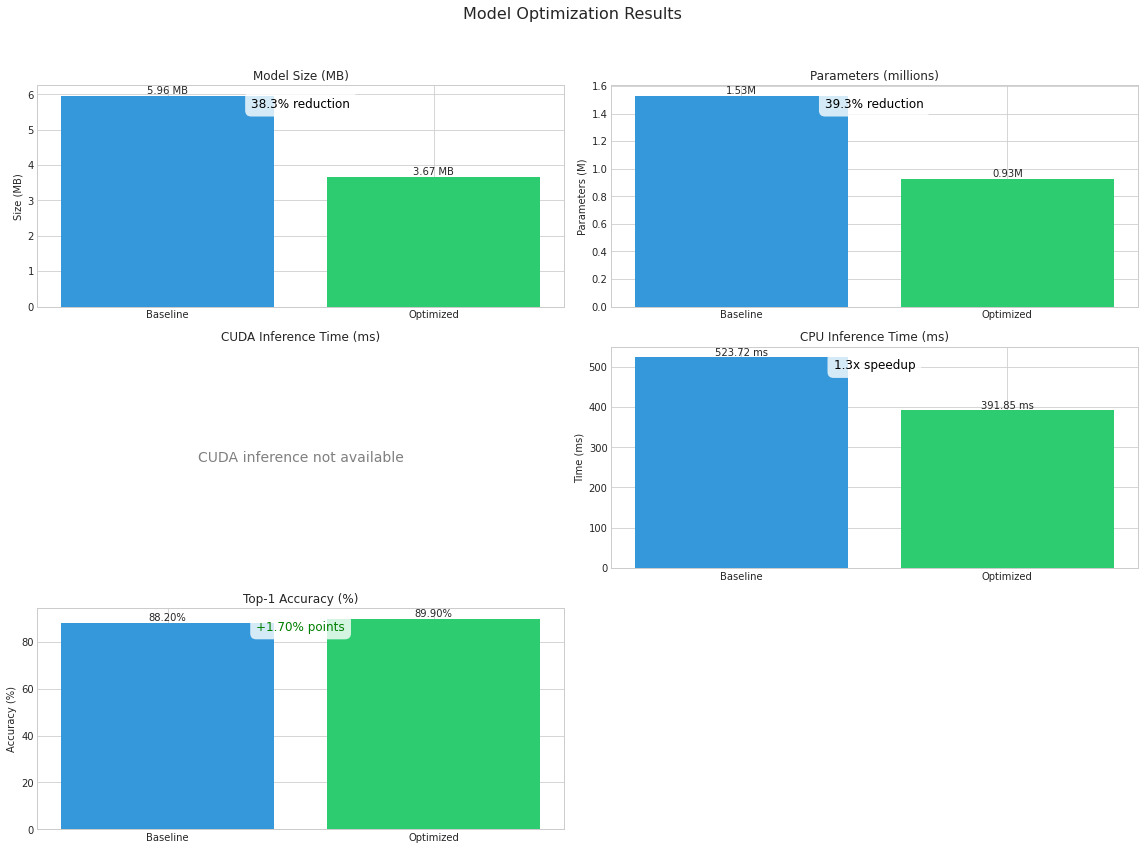


post_training/quantization/dynamic Results:
Model Size: 3.67 MB (38.3% reduction)
Parameters: 927,008 (39.3% reduction)
CPU Inference Time: 391.85 ms (1.3x speedup)
Accuracy: 89.90% (+1.70% change)
Requirements met: False

--------------------------------------------------
Step 3: GraphOpt
--------------------------------------------------

Applying optimization with torch_fx as method
Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.04it/s]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.21it/s]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


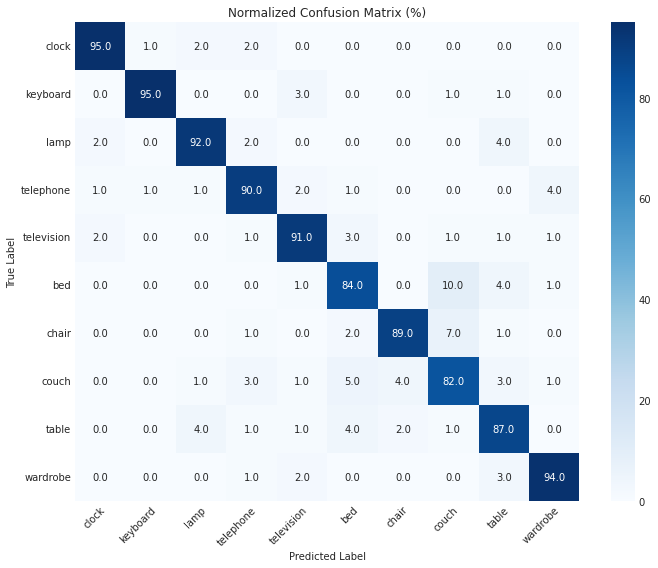


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 89.90%
Model Size: 3.56 MB
CPU Inference Time: 360.04 ms (2.78 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.85it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.29it/s]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


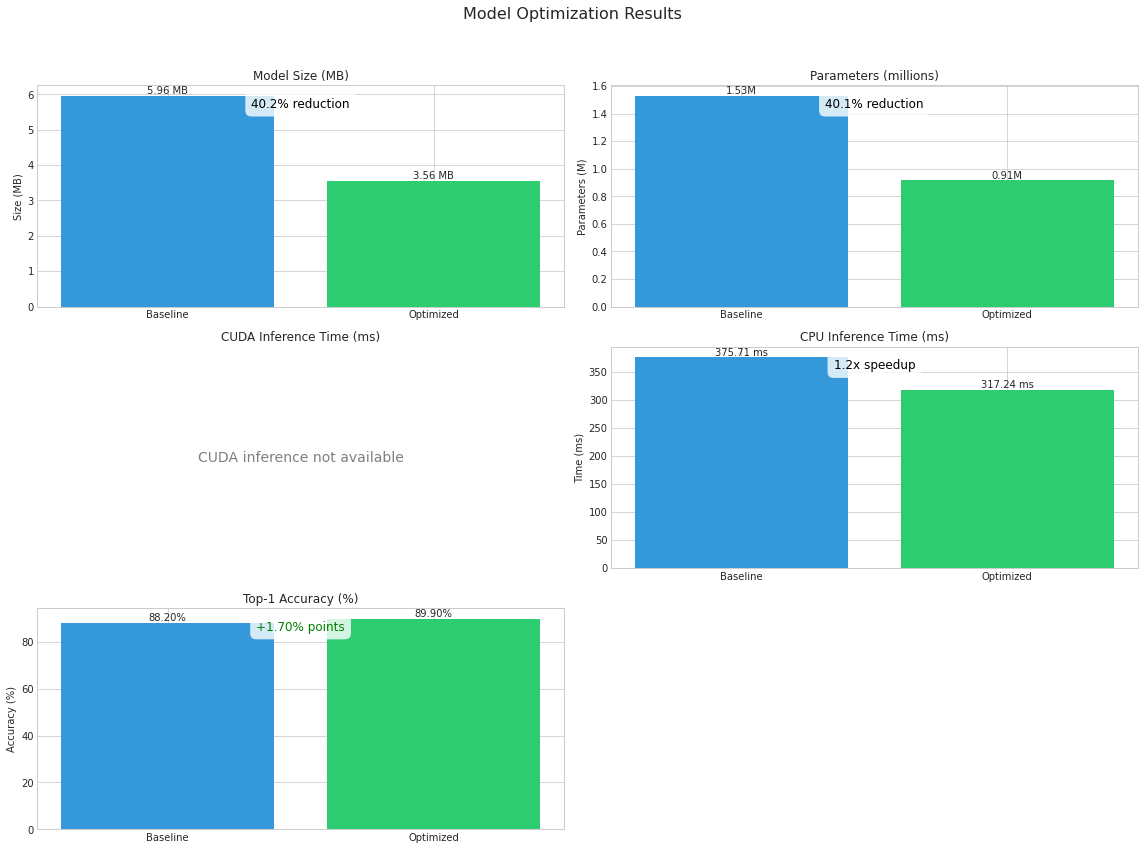


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 3.56 MB (40.2% reduction)
Parameters: 914,896 (40.1% reduction)
CPU Inference Time: 317.24 ms (1.2x speedup)
Accuracy: 89.90% (+1.70% change)
Requirements met: False
Model saved to ../models/pipeline/DistillQuantGraphOpt/model.pth

Pipeline DistillQuantGraphOpt completed



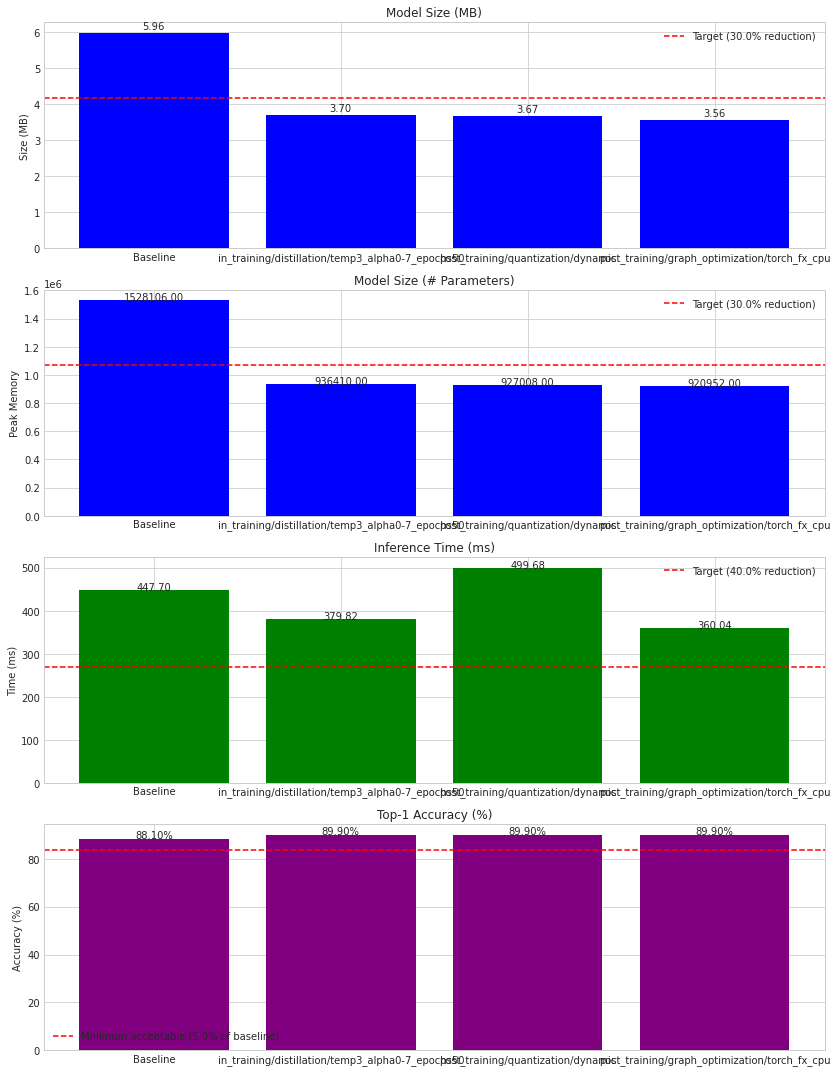


Pipeline DistillQuantGraphOpt Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 3.56 MB
  Reduction: 40.20%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 920952.00 MB
  Reduction: 39.73%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 447.70 ms
  Final: 360.04 ms
  Reduction: 19.58%
  ❌ Does not meet target (Goal: 268.62 ms)

Accuracy:
  Baseline: 88.10%
  Final: 89.90%
  Change: 2.04%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ❌ Pipeline does not meet all requirements


In [18]:
# Create and run Pipeline #4

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "DistillQuantGraphOpt"  

# Initialize the pipeline
pipeline4 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=None,
    train_loader=None,
    test_loader=None,
    class_names=None,
    input_size=None
)

# TODO: Add optimization steps using the add_step() function
pipeline4.add_step(step_name="Distill", step_function=apply_knowledge_distillation, model=None)
pipeline4.add_step(step_name="Quant",step_function=apply_dynamic_quantization)
pipeline4.add_step(step_name="GraphOpt",step_function=apply_graph_optimization)

print(pipeline4.steps)

# Run the pipeline
optimized_model_p4 = pipeline4.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device('cpu')  # Define as torch.device()
pipeline4.visualize_results(baseline_metrics, device)


[{'name': 'QAT', 'function': <function apply_quantization_aware_training at 0x7d15dc9e70a0>, 'args': {'model': None}}, {'name': 'GraphOpt', 'function': <function apply_graph_optimization at 0x7d15dc9e67a0>, 'args': {}}]

Running pipeline: QATGraphOpt


--------------------------------------------------
Step 1: QAT
--------------------------------------------------

QuantizableMobileNetV3_Household_qat(
  (model): QuantizableMobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): QuantizableInvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=Tru

Epoch 1/200 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.27it/s, loss=2.23, acc=23.5]


plateau scheduler stepped
Epoch 1/200 - Train Loss: 2.2466, Train Acc: 21.42%, Test Loss: 2.2256, Test Acc: 23.50%, LR: 0.010000, Time: 7.00s
New best quantized model! Saving... (23.50%)
Model saved to /home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start/checkpoints


Epoch 2/200 [Test]: 100%|██████████| 8/8 [00:02<00:00,  3.22it/s, loss=2.2, acc=19.4] 


plateau scheduler stepped
Epoch 2/200 - Train Loss: 2.0628, Train Acc: 38.00%, Test Loss: 2.1957, Test Acc: 19.40%, LR: 0.010000, Time: 6.87s


...

plateau scheduler stepped
Epoch 200/200 - Train Loss: 0.0127, Train Acc: 100.00%, Test Loss: 0.5213, Test Acc: 86.70%, LR: 0.003487, Time: 7.36s
Training completed. Best accuracy: 87.70%
Best QAT model saved as '/home/ubuntu/proj_root/../models/in_training/quantization/epochs200_start/checkpoints' at epoch 189
Converting best QAT model to fully quantized model...
Model saved to ../models/in_training/quantization/epochs200_start/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]


Baseline metrics saved at ../results/in_training/quantization/epochs200_start/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]


Confusion matrix saved to ../results/in_training/quantization/epochs200_start/confusion_matrix.png


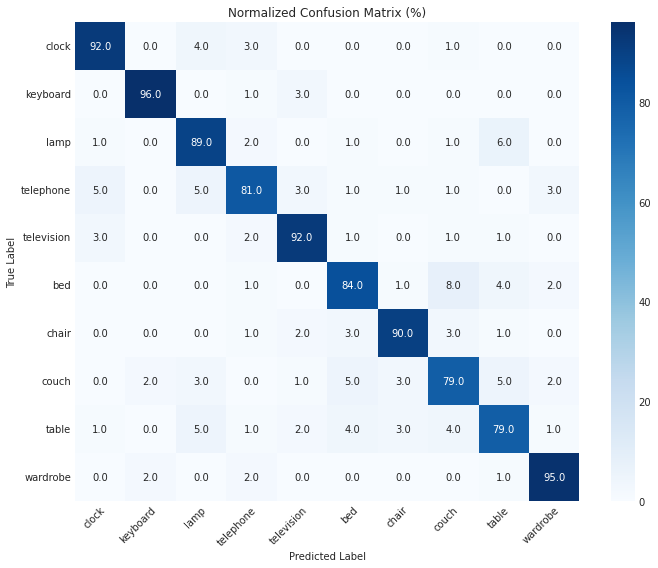

No suitable layers found for weight distribution visualization.
Training history plot saved to ../results/in_training/quantization/epochs200_start/training_history.png


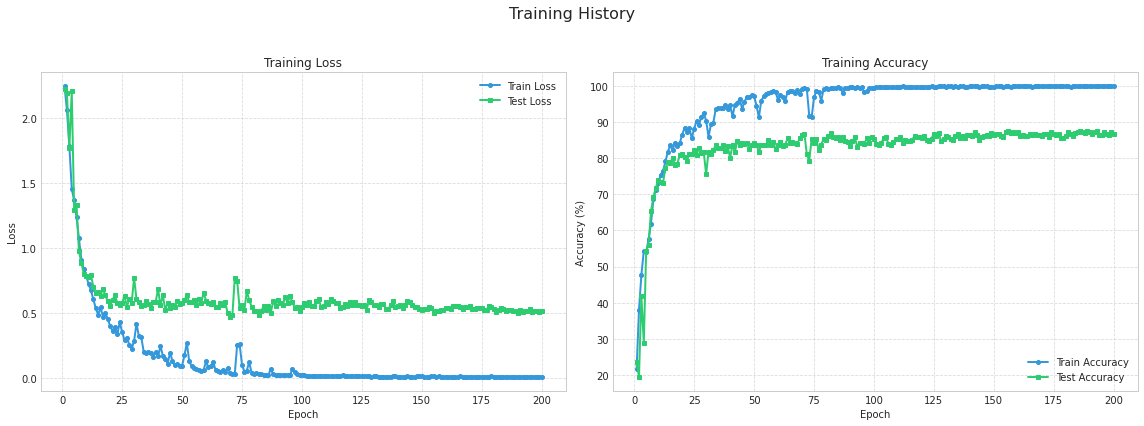


Optimized Model Metrics (in_training/quantization/epochs200_start):
Accuracy: 87.60%
Model Size: 1.58 MB
CPU Inference Time: 40.68 ms (24.58 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.03it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.31it/s]


Model comparison plot saved to ../results/in_training/quantization/epochs200_start/comparison.png


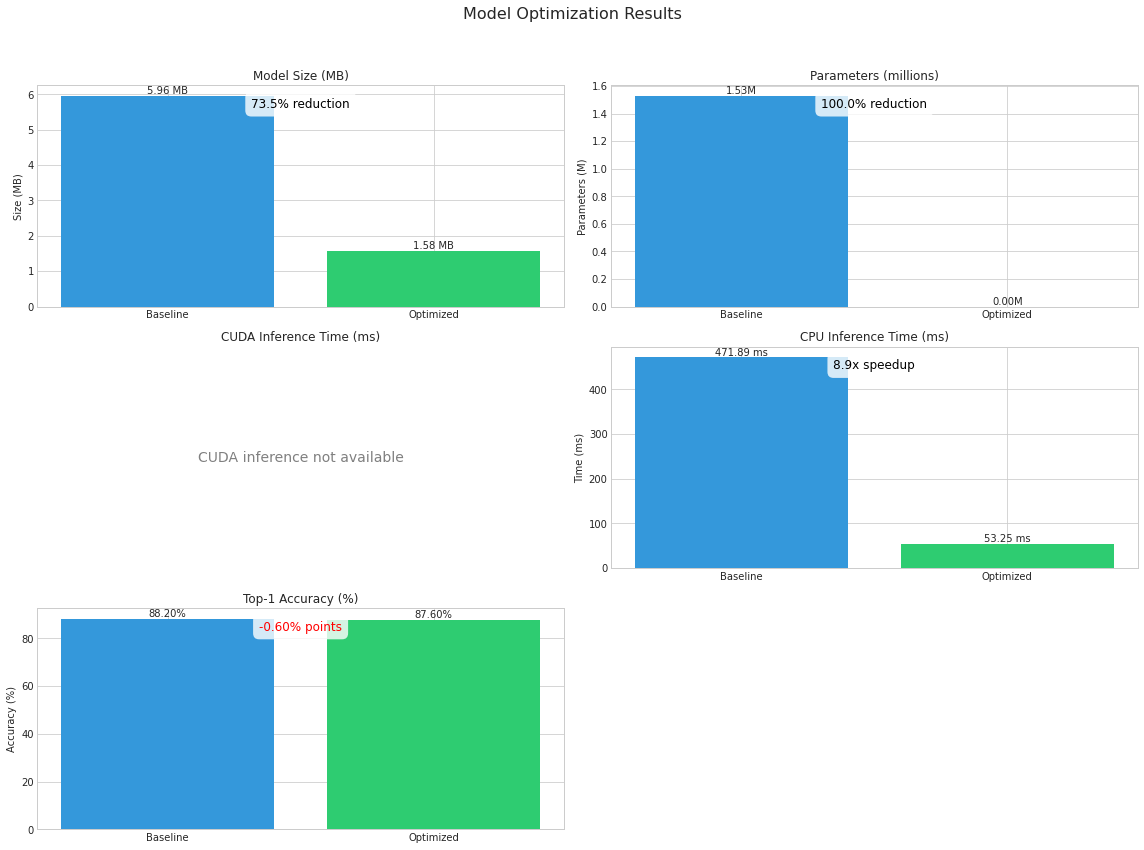


in_training/quantization/epochs200_start Results:
Model Size: 1.58 MB (73.5% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 53.25 ms (8.9x speedup)
Accuracy: 87.60% (-0.60% change)
Requirements met: True

--------------------------------------------------
Step 2: GraphOpt
--------------------------------------------------

Applying optimization with torch_fx as method
Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.87it/s]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


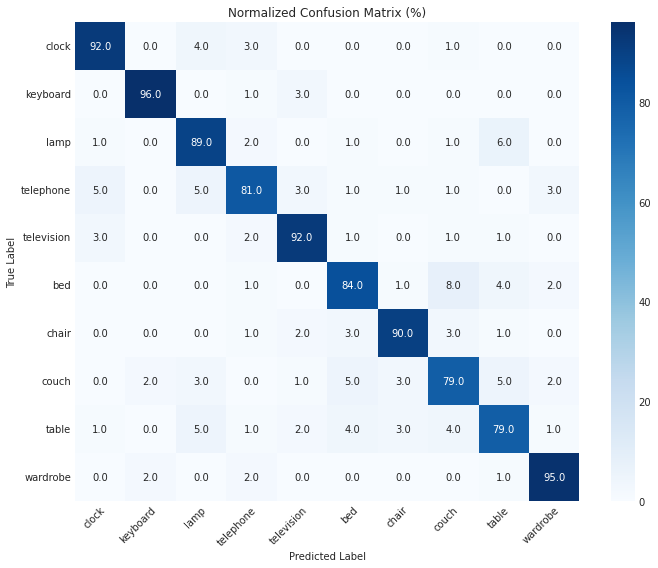


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 87.60%
Model Size: 1.57 MB
CPU Inference Time: 65.26 ms (15.32 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.89it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


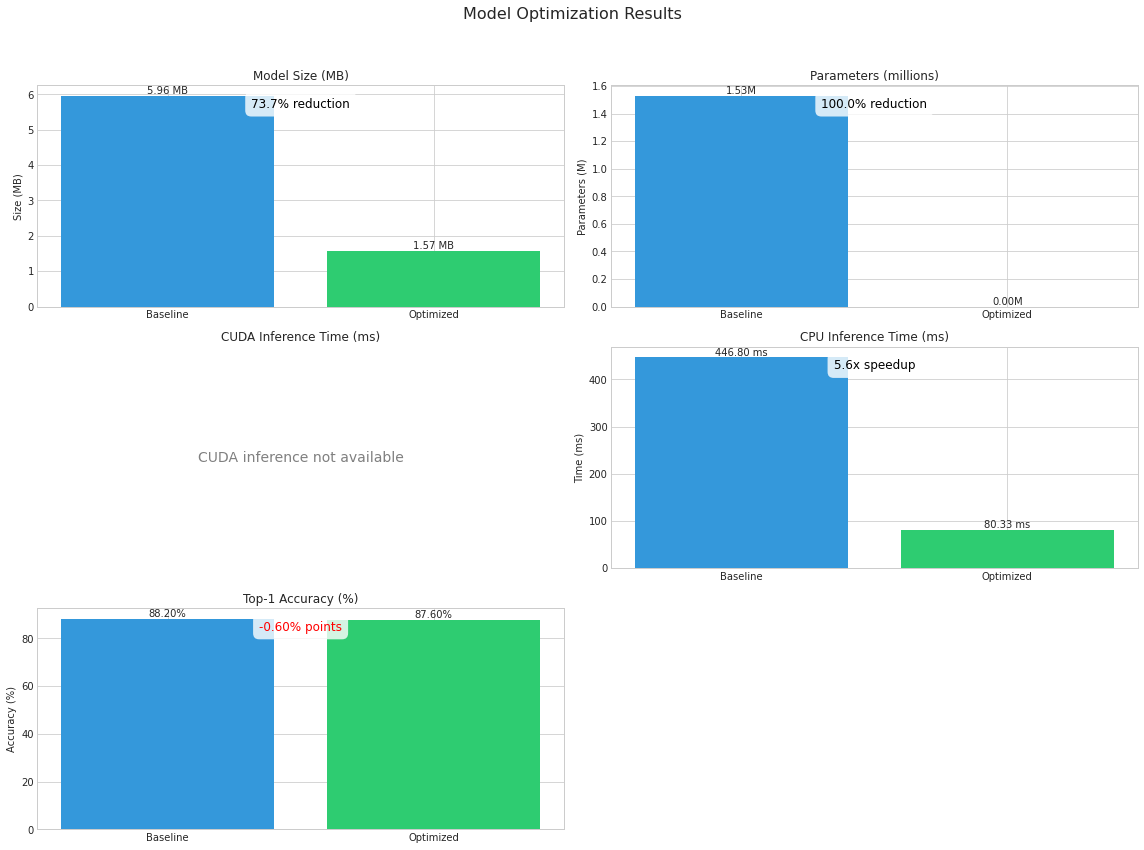


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 1.57 MB (73.7% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 80.33 ms (5.6x speedup)
Accuracy: 87.60% (-0.60% change)
Requirements met: True
Model saved to ../models/pipeline/QATGraphOpt/model.pth

Pipeline QATGraphOpt completed



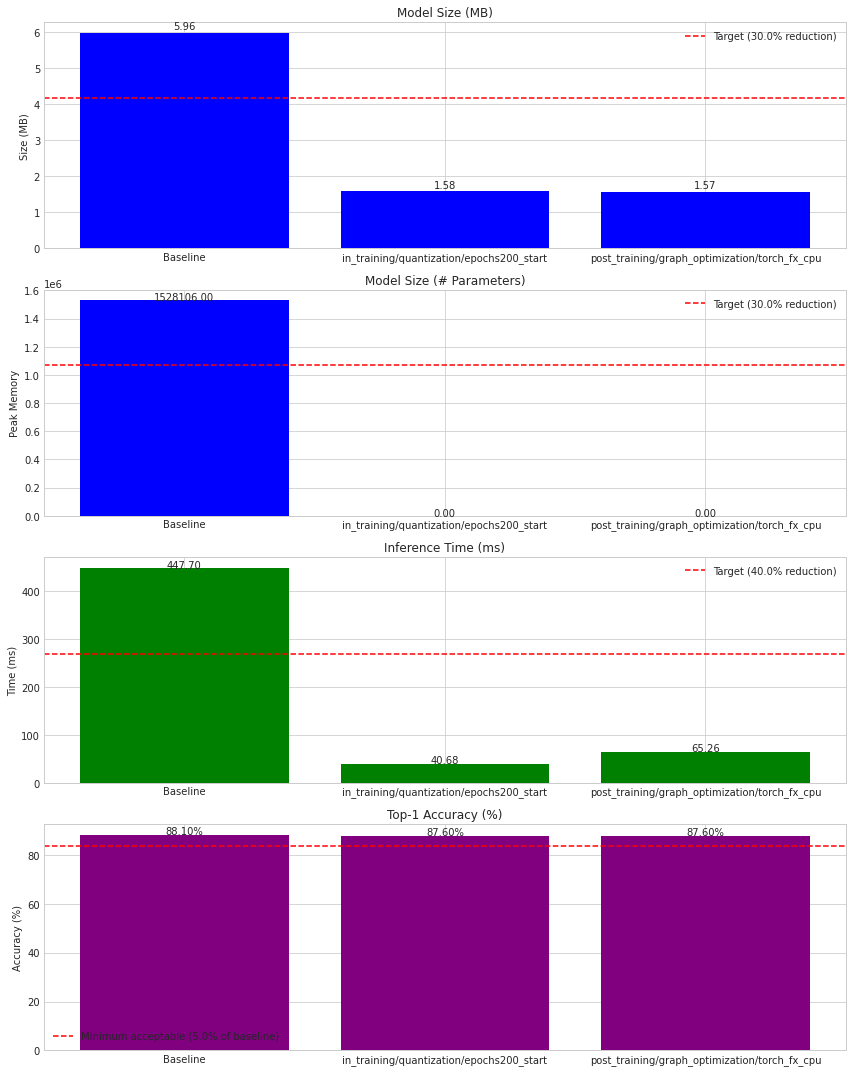


Pipeline QATGraphOpt Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 1.57 MB
  Reduction: 73.69%
  ✅ Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 0.00 MB
  Reduction: 100.00%
  ✅ Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 447.70 ms
  Final: 65.26 ms
  Reduction: 85.42%
  ✅ Meets target (40.0% reduction)

Accuracy:
  Baseline: 88.10%
  Final: 87.60%
  Change: -0.57%
  ✅ Meets target (within 5.0% of baseline)

Overall Assessment:
  ✅ Pipeline meets all requirements


In [19]:
# Create and run Pipeline #5

# TODO: Choose a meaningful and unique pipeline name 
pipeline_name = "QATGraphOpt"  

# Initialize the pipeline
pipeline5 = OptimizationPipeline(
    name=pipeline_name,
    baseline_model=None,
    train_loader=None,
    test_loader=None,
    class_names=None,
    input_size=None
)

# TODO: Add optimization steps using the add_step() function
pipeline5.add_step(step_name="QAT", step_function=apply_quantization_aware_training, model=None)
pipeline5.add_step(step_name="GraphOpt",step_function=apply_graph_optimization)

print(pipeline5.steps)

# Run the pipeline
optimized_model_p5 = pipeline5.run()

# Visualize the results
# TODO: Choose the device to report performance for
device = torch.device('cpu') # Define as torch.device()
pipeline5.visualize_results(baseline_metrics, device)

### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [76]:
from utils.compression import compare_pipeline_experiments

In [77]:
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/",
                                                                                           metrics_filename="pipeline_metrics.json")]

In [78]:
pipeline_experiments

['pipeline/DistillGraphOpt',
 'pipeline/DistillQuant',
 'pipeline/DistillQuantGraphOpt',
 'pipeline/QATGraphOpt',
 'pipeline/QuantGraphOpt']

In [79]:
# Compare all implemented pipelines
if pipeline_experiments:
    _ = compare_pipeline_experiments(pipeline_experiments, baseline_name="baseline_mobilenet")
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,baseline_mobilenet,5.96,0.0%,447.70,0.0x,88.10,+0.0%,✗
1,pipeline/DistillGraphOpt,3.59,39.8%,305.33,1.5x,89.60,+1.7%,✗
2,pipeline/DistillQuant,3.67,38.3%,384.56,1.2x,89.30,+1.4%,✗
3,pipeline/DistillQuantGraphOpt,3.56,40.2%,360.04,1.2x,89.90,+2.0%,✗
4,pipeline/QATGraphOpt,1.57,73.7%,65.26,6.9x,87.60,-0.6%,✓
5,pipeline/QuantGraphOpt,4.13,30.7%,280.91,1.6x,88.10,+0.0%,✗


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model  

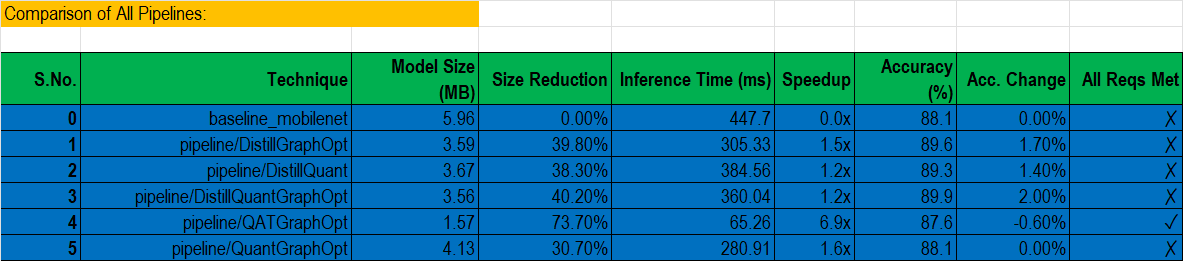

Comparison of optimized models obtained post completion of respective pipelines can be seen in table defined above.
We will discuss few which came pretty close to target inference time and the one which beat the targets comprehensively.
All optimized models beat the target set for model size(4.172 MB)  and accuracy (83.1%).
Where the optimized models differ is inference times(target: 268.62 ms):

1) pipeline/QATGraphOpt is clear winner. It beats all the targets comprehensively where it achieves final inference time of 65.26 ms which is pretty nice with 6.9x speed up over original model. Final model size is exceptionally small(1.57MB) with 87.6% accuracy. Actually QAT is capable of adding more fractions to final accuracy as we saw in phase 2 where we did all the standalone experiments- it achieved accuracy of 88.6%. 

2) pipeline/DistillGraphOpt comes pretty close to inference time target achieving speed up of 1.5x (305.33 ms)

3) pipeline/QuantGraphOpt also comes very close to inference time target achieving a speed up of 1.6x(280.91 ms)

Rest 2 achieve a speed up of 1.2x


All the stages in different pipelines showed expected behavior as observed in phase 2. 
Anomalies could be observed with respect to inference times. I will try to explain this with an observation on pipeline 2. 

Each of the experiment carries inference twice - first stage when it measures the statistics on optimized model; second stage when it compares the original model stats with that of optimized model and it runs inference loops both times. I can observe inference time differences between two stages. To give an example of pipeline 2, we achieve inference time of 255.35 ms (1.6x speedup) during stage 2 of graph optimization. In stage 1 it drops to 305.33 ms thus missing the mark. If we take stage 2 stats, then it meets all the final target criteria.  This anomaly can be attributed to the fact that we run all the compute environments in cloud in shared mode where CPUs are shared- we call vCPUs. Depending on the load on physical node it resides on, and the memory usage, inference time can vary between different runs.The final stats that are reported are based on stage 1 run.

pipeline2:
-----------
**Stage 1**
Optimized Model Metrics (in_training/distillation/temp3_alpha0-7_epochs50):

Accuracy: 89.50%

Model Size: 3.70 MB

CPU Inference Time: 414.00 ms (2.42 FPS)

CUDA Inference Time: 3.26 ms (306.58 FPS)


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):

Accuracy: 89.60%

Model Size: 3.59 MB

CPU Inference Time: 305.33 ms (3.28 FPS)

CUDA Inference Time: 2.66 ms (375.64 FPS)

**Stage 2**
##############################################################
post_training/graph_optimization/torch_fx_cpu Results:

Model Size: 3.59 MB (39.7% reduction)

Parameters: 924,298 (39.5% reduction)

CPU Inference Time: 255.35 ms (1.6x speedup) -->> **This is less than target inference time of 268.62 ms**

CUDA Inference Time: 2.72 ms (1.2x speedup)

Accuracy: 89.60% (+1.40% change)

Requirements met: False

Model saved to ../models/pipeline/DistillGraphOpt/model.pth
###############################################################


MobileNetV3 has quite complex but efficient architecture with maximum computation happening in backbone. Model turns dense Conv2d computations into more efficient parallel depth wise separable convolutions using Inverted Residual and Squeeze Excitation blocks. 
To get better speed up on model, we need to trim the backbone. 
If we trim the backbone, we need to train the model from scratch. If we train model with trimmed backbone from scratch we are not able to achieve the target accuracy set as we lose out on the generalization capability that comes with pretrained model. Still we can trim down model size by 35-40% without compromising on the accuracy by reducing the intermediate size of linear layers in classifier block.

Experiments carried out in phase 2 and observations made were quite accurate and chosen pipeline optimization combos worked pretty well together as expected. The only anomaly observed was with respect to inference times which has already been discussed in great detail earlier.

Further we can think of following potential improvements:
1) Run the experiments on standalone machines (no sharing of CPUs or memory). This will give accurate measure of inference timings. I am pretty sure pipeline/DistillGraphOpt and 	pipeline/QuantGraphOpt will meet the inference targets.
2) Clean up memory and CPU by unloading all previous models and variables as it might contribute to minor fluctuations observed. This should be done before running inference run on final optimized model of respective pipelines
3) Run the inference on final model multiple times (say 5 or 10 times) and then take average of all to arrive at more realistic inference figure. From that we can see standard deviation of all the runs. We should determine the acceptable deviation from mean. If deviation is huge then we should diagnose further before making final decision. If it is within acceptable deviation then model should be good to go.
4) Following the procedure in step 3, we can get more realistic inference time expectation of pipelines other than QATGraphOpt and chances are high that these might meet target inference time. However QAT though tricky and time consuming to implement makes the competition unfair by setting extremely high standard on model size and inference time without compromising on the final accuracy.
5) More experiments can be carried out to trim the backbone of MobileNetV3 small model and retrain from scratch and see if we can still get to target accuracy. Another way will be to tweak into the layer sizing of last block of backbone. This way we can still keep the pretrained learning of earlier layers of backbone and then it should be possible to reach the accuracy targets and better inference times.
6) We can run QAT training on Distilled model to further bring down model size and inference time.

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  